# Mini-Project 2: Semantic Segmentation — Pascal VOC 2007
**Course**: SHBT261 | **Deadline**: April 15, 2026

Single-notebook Colab pipeline. Run blocks top-to-bottom without restarting the runtime.

---
## Block 0 — Install Dependencies
Run once at the start of every Colab session. All packages installed here; nothing installed later.

In [1]:
# Block 0 — pip install (run once; safe to re-run)
# ─────────────────────────────────────────────────────────────────────────────
# Core ML / vision
!pip install torch torchvision torchaudio --quiet

# Metrics + scientific computing
!pip install torchmetrics scipy scikit-learn --quiet

# Visualisation + utilities
!pip install matplotlib pillow numpy pandas --quiet

# Kaggle API (dataset download)
!pip install kaggle --quiet

# SAM2 (Meta) — install from source; pinning to the stable release tag
!pip install 'git+https://github.com/facebookresearch/sam2.git' --quiet

# ── Verify key imports ────────────────────────────────────────────────────────
import importlib, sys

required = [
    ('torch',        'torch'),
    ('torchvision',  'torchvision'),
    ('torchmetrics', 'torchmetrics'),
    ('scipy',        'scipy'),
    ('sklearn',      'scikit-learn'),
    ('matplotlib',   'matplotlib'),
    ('PIL',          'pillow'),
    ('numpy',        'numpy'),
    ('sam2',         'sam2'),
]

all_ok = True
for module, pkg in required:
    found = importlib.util.find_spec(module) is not None
    status = '✓' if found else '✗ MISSING'
    if not found:
        all_ok = False
    print(f'  {status}  {pkg}')

import torch
gpu = torch.cuda.is_available()
print()
print(f'  GPU available : {gpu}')
if gpu:
    print(f'  GPU name      : {torch.cuda.get_device_name(0)}')
    print(f'  CUDA version  : {torch.version.cuda}')
else:
    print('  ⚠ No GPU detected — connect to a GPU runtime before continuing.')

print()
if all_ok and gpu:
    print('Block 0 ✓  All dependencies installed. GPU confirmed. Ready for Block 1.')
elif all_ok:
    print('Block 0 ⚠  Packages OK but no GPU — switch runtime type before Block 10 (training).')
else:
    print('Block 0 ✗  Some packages failed to install — check the output above.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.9 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 7.1 MB/s eta 0:00:00
  ✓  torch
  ✓  torchvision
  ✓  torchmetrics
  ✓  scipy
  ✓  scikit-learn
  ✓  matplotlib
  ✓  pillow
  ✓  numpy
  ✓  sam2

  GPU available : True
  GPU name      : NVIDIA A100-SXM4-40GB
  CUDA version  : 12.8

Block 0 ✓  All dependencies installed. GPU confirmed. Ready for Block 1.


---
## Block 1 — Drive Mount, Project Directories & Config

Mounts Google Drive, creates the full directory tree, and writes `config.json` with all
hyperparameters and path constants.  Everything downstream reads from `CFG` in memory —
no cross-notebook file dependency.

In [2]:
# Block 1 — Drive mount, project directories, config
# ─────────────────────────────────────────────────────────────────────────────
import os, json
from pathlib import Path
from google.colab import drive

# ── 1. Mount Drive ────────────────────────────────────────────────────────────
MOUNT_POINT = '/content/drive'
if not os.path.ismount(MOUNT_POINT):
    drive.mount(MOUNT_POINT)
    print('Drive mounted.')
else:
    print('Drive already mounted.')

# ── 2. Project root on Drive ─────────────────────────────────────────────────
PROJECT_ROOT = Path('/content/drive/MyDrive/SHBT261_mini_proj2')

DIRS = {
    'root':        PROJECT_ROOT,
    'checkpoints': PROJECT_ROOT / 'checkpoints',
    'metrics':     PROJECT_ROOT / 'metrics',
    'predictions': PROJECT_ROOT / 'predictions',
    'figures':     PROJECT_ROOT / 'figures',
    'logs':        PROJECT_ROOT / 'logs',
}

for name, path in DIRS.items():
    path.mkdir(parents=True, exist_ok=True)
    print(f'  {"created" if not path.exists() else "exists  "}  {path}')

# ── 3. Config — single source of truth for all hyperparameters ───────────────
CFG = {
    # Paths (as strings so JSON-serialisable)
    'project_root':   str(DIRS['root']),
    'checkpoints':    str(DIRS['checkpoints']),
    'metrics':        str(DIRS['metrics']),
    'predictions':    str(DIRS['predictions']),
    'figures':        str(DIRS['figures']),
    'logs':           str(DIRS['logs']),
    'voc_root':       '/content/VOCdata',          # set properly after extraction in Block 2
    'drive_zip_dir':  str(DIRS['root']),            # where the Kaggle zip is stored on Drive

    # Dataset
    'img_size':       [256, 256],
    'num_classes':    21,
    'voc_classes': [
        'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
        'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
        'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
    ],
    'ignore_index':   255,
    'imagenet_mean':  [0.485, 0.456, 0.406],
    'imagenet_std':   [0.229, 0.224, 0.225],

    # Training
    'num_epochs':     30,
    'batch_size':     8,
    'lr':             1e-3,
    'weight_decay':   1e-4,
    'scheduler':      'CosineAnnealingLR',

    # Ablation toggles (changed per variant in Block 15)
    'use_augmentation': True,
    'loss_fn':          'ce',   # 'ce' | 'dice'

    # SAM2
    'sam2_ckpt_dir':  '/content/sam2_checkpoints',
    'sam2_ckpt_url':  'https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_base_plus.pt',
    'sam2_n_eval':    200,      # images to run SAM2 on (full val=2510; 200 for speed)
}

# Save to Drive so it survives a runtime crash
cfg_path = DIRS['root'] / 'config.json'
with open(cfg_path, 'w') as f:
    json.dump(CFG, f, indent=2)

# ── 4. Verification printout ──────────────────────────────────────────────────
print()
print('=== Config ===')
for k, v in CFG.items():
    if k == 'voc_classes':
        print(f'  {k:20s}: {v[:4]} ... ({len(v)} classes)')
    else:
        print(f'  {k:20s}: {v}')

print()
print(f'Config written to : {cfg_path}')
print(f'Config file size  : {cfg_path.stat().st_size} bytes')
print()

# Confirm all dirs actually exist on Drive
all_dirs_ok = all(path.is_dir() for path in DIRS.values())
print(f'All project dirs exist on Drive : {all_dirs_ok}')
print()
if all_dirs_ok:
    print('Block 1 ✓  Drive mounted, dirs created, config saved. Ready for Block 2.')
else:
    print('Block 1 ✗  Some directories were not created — check Drive permissions.')

Mounted at /content/drive
Drive mounted.
  exists    /content/drive/MyDrive/SHBT261_mini_proj2
  exists    /content/drive/MyDrive/SHBT261_mini_proj2/checkpoints
  exists    /content/drive/MyDrive/SHBT261_mini_proj2/metrics
  exists    /content/drive/MyDrive/SHBT261_mini_proj2/predictions
  exists    /content/drive/MyDrive/SHBT261_mini_proj2/figures
  exists    /content/drive/MyDrive/SHBT261_mini_proj2/logs

=== Config ===
  project_root        : /content/drive/MyDrive/SHBT261_mini_proj2
  checkpoints         : /content/drive/MyDrive/SHBT261_mini_proj2/checkpoints
  metrics             : /content/drive/MyDrive/SHBT261_mini_proj2/metrics
  predictions         : /content/drive/MyDrive/SHBT261_mini_proj2/predictions
  figures             : /content/drive/MyDrive/SHBT261_mini_proj2/figures
  logs                : /content/drive/MyDrive/SHBT261_mini_proj2/logs
  voc_root            : /content/VOCdata
  drive_zip_dir       : /content/drive/MyDrive/SHBT261_mini_proj2
  img_size            : [2

---
## Block 2 — Dataset Download & Extraction

Downloads Pascal VOC 2007 from Kaggle **once** and stores the zip on Drive.
On subsequent sessions it copies the zip from Drive → local SSD and extracts it there
(faster I/O during training).

**Before running:** upload your `kaggle.json` when prompted.  
You only need to do this once per Colab session.

In [5]:
# Block 2 — Dataset download & extraction
# ─────────────────────────────────────────────────────────────────────────────
import os, shutil, glob, pathlib, json
from pathlib import Path

DRIVE_ZIP_DIR = CFG['drive_zip_dir']     # /content/drive/MyDrive/SHBT261_mini_proj2
LOCAL_DATA    = CFG['voc_root']          # /content/VOCdata
os.makedirs(DRIVE_ZIP_DIR, exist_ok=True)

# ── Step 1: Check what's already on Drive ────────────────────────────────────
existing_zips = glob.glob(os.path.join(DRIVE_ZIP_DIR, '*.zip'))
print(f'Zips already on Drive : {existing_zips}')

# ── Step 2: Only ask for Kaggle creds if we actually need to download ─────────
if not existing_zips:
    from google.colab import files
    kaggle_cfg = os.path.expanduser('~/.kaggle/kaggle.json')
    if not os.path.exists(kaggle_cfg):
        print('No zip on Drive and no kaggle.json — upload kaggle.json now...')
        uploaded = files.upload()
        os.makedirs(os.path.dirname(kaggle_cfg), exist_ok=True)
        for fname in uploaded:
            shutil.move(fname, kaggle_cfg)
        os.chmod(kaggle_cfg, 0o600)
        print(f'kaggle.json installed at {kaggle_cfg}')

    print('Downloading Pascal VOC 2007 from Kaggle → Drive (one-time, ~870 MB)...')
    ret = os.system(
        f'kaggle datasets download -d zaraks/pascal-voc-2007 -p "{DRIVE_ZIP_DIR}"'
    )
    if ret != 0:
        raise RuntimeError('Kaggle download failed — check kaggle.json and dataset slug.')
    existing_zips = glob.glob(os.path.join(DRIVE_ZIP_DIR, '*.zip'))
    print(f'Download complete. Zip saved: {existing_zips}')
else:
    print('Zip already on Drive — skipping download and kaggle.json entirely.')

assert existing_zips, 'No zip found on Drive after download step.'

# ── Step 3: Copy zip Drive → local SSD & extract (skip if already extracted) ─
already_extracted = (
    os.path.isdir(LOCAL_DATA) and
    bool(list(pathlib.Path(LOCAL_DATA).rglob('VOCdevkit')))
)

if already_extracted:
    print(f'\nDataset already extracted at {LOCAL_DATA} — skipping extraction.')
else:
    trainval_zips = [z for z in existing_zips if 'trainval' in z.lower()]
    src_zip = trainval_zips[0] if trainval_zips else existing_zips[0]
    local_zip = '/content/voc_dataset.zip'

    print(f'\nCopying {src_zip} → {local_zip} ...')
    shutil.copy(src_zip, local_zip)
    print(f'Copied ({os.path.getsize(local_zip) / 1e6:.1f} MB). Extracting...')

    os.makedirs(LOCAL_DATA, exist_ok=True)
    ret = os.system(f'unzip -q "{local_zip}" -d "{LOCAL_DATA}"')
    if ret != 0:
        raise RuntimeError('unzip failed — zip may be corrupted.')
    os.remove(local_zip)
    print('Extraction complete.')

# ── Step 4: Auto-detect VOC_ROOT and update CFG ───────────────────────────────
voc_devkits = list(pathlib.Path(LOCAL_DATA).rglob('VOCdevkit'))
assert voc_devkits, f'VOCdevkit not found under {LOCAL_DATA} — extraction may have failed.'

trainval_hits = [c for c in voc_devkits if 'trainval' in str(c).lower()]
best_devkit   = trainval_hits[0] if trainval_hits else voc_devkits[0]
VOC_ROOT      = str(best_devkit.parent)

CFG['voc_root'] = VOC_ROOT
with open(Path(CFG['project_root']) / 'config.json', 'w') as f:
    json.dump(CFG, f, indent=2)

# ── Step 5: Verification ──────────────────────────────────────────────────────
img_dir   = os.path.join(VOC_ROOT, 'VOCdevkit', 'VOC2007', 'JPEGImages')
mask_dir  = os.path.join(VOC_ROOT, 'VOCdevkit', 'VOC2007', 'SegmentationClass')
split_dir = os.path.join(VOC_ROOT, 'VOCdevkit', 'VOC2007', 'ImageSets', 'Segmentation')

n_images = len(os.listdir(img_dir))
n_masks  = len(os.listdir(mask_dir))
splits   = {}
for fname in os.listdir(split_dir):
    if fname.endswith('.txt'):
        with open(os.path.join(split_dir, fname)) as fh:
            splits[fname.replace('.txt', '')] = len(fh.readlines())

print(f'\n=== Dataset Verification ===')
print(f'  VOC_ROOT              : {VOC_ROOT}')
print(f'  Total JPEG images     : {n_images}  (full detection set)')
print(f'  Total seg. masks      : {n_masks}   (segmentation subset only)')
print(f'  Segmentation splits:')
for split, count in sorted(splits.items()):
    marker = '← used for training' if split == 'train' else ('← used as TEST set (assignment)' if split == 'val' else '')
    print(f'    {split:10s}: {count:4d} images  {marker}')

# NOTE: VOC 2007 segmentation is a small subset of the full detection dataset.
# Correct expected sizes: train ~209, val ~213, trainval ~422.
assert n_images > 0,       'No JPEG images found!'
assert n_masks  > 0,       'No segmentation masks found!'
assert 'train'  in splits, 'train split missing!'
assert 'val'    in splits, 'val split missing!'
assert splits['train'] > 50, f'Unexpectedly few train images: {splits["train"]}'
assert splits['val']   > 50, f'Unexpectedly few val images: {splits["val"]}'

print()
print(f'CFG["voc_root"] updated → {CFG["voc_root"]}')
print('Config re-saved to Drive.')
print()
print('Block 2 ✓  Dataset ready. VOC_ROOT confirmed. Ready for Block 3.')

Zips already on Drive : ['/content/drive/MyDrive/SHBT261_mini_proj2/pascal-voc-2007.zip']
Zip already on Drive — skipping download and kaggle.json entirely.

Dataset already extracted at /content/VOCdata/voctrainval_06-nov-2007 — skipping extraction.

=== Dataset Verification ===
  VOC_ROOT              : /content/VOCdata/voctrainval_06-nov-2007
  Total JPEG images     : 5011  (full detection set)
  Total seg. masks      : 422   (segmentation subset only)
  Segmentation splits:
    train     :  209 images  ← used for training
    trainval  :  422 images  
    val       :  213 images  ← used as TEST set (assignment)

CFG["voc_root"] updated → /content/VOCdata/voctrainval_06-nov-2007
Config re-saved to Drive.

Block 2 ✓  Dataset ready. VOC_ROOT confirmed. Ready for Block 3.


---
## Block 3 — Global Definitions
Define once, reuse everywhere: VOC constants, colour palette, helper functions, and the
`VOCSegmentationSync` dataset class (synchronized image+mask augmentation).

In [6]:
# Block 3 — Global definitions (run once; all downstream blocks depend on these)
# ─────────────────────────────────────────────────────────────────────────────
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torchvision import transforms
from torchvision.datasets import VOCSegmentation
from torchvision.transforms import functional as TF
from torch.utils.data import Dataset

# ── 1. Classes & mapping (from assignment starter code) ───────────────────────
VOC_CLASSES = CFG['voc_classes']
NUM_CLASSES = CFG['num_classes']
IMG_SIZE    = tuple(CFG['img_size'])
IGNORE_IDX  = CFG['ignore_index']
MEAN        = np.array(CFG['imagenet_mean'])
STD         = np.array(CFG['imagenet_std'])
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

print('Pascal VOC 2007 Class Mapping:')
class_mapping = {i: cls for i, cls in enumerate(VOC_CLASSES)}
for idx, name in class_mapping.items():
    print(f'  {idx:2d}  {name}')
print(f'\nNUM_CLASSES : {NUM_CLASSES}')
print(f'DEVICE      : {DEVICE}')
print(f'IMG_SIZE    : {IMG_SIZE}')

# ── 2. VOC colour palette (21 classes) ───────────────────────────────────────
VOC_COLORMAP = np.array([
    [0,0,0],   [128,0,0],   [0,128,0],   [128,128,0],   [0,0,128],
    [128,0,128],[0,128,128], [128,128,128],[64,0,0],      [192,0,0],
    [64,128,0],[192,128,0],  [64,0,128],  [192,0,128],   [64,128,128],
    [192,128,128],[0,64,0],  [128,64,0],  [0,192,0],     [128,192,0],
    [0,64,128]
], dtype=np.uint8)

# ── 3. Helper functions ───────────────────────────────────────────────────────
def denormalize(tensor):
    """(C,H,W) normalised tensor → (H,W,C) float32 numpy in [0,1]."""
    img = tensor.permute(1, 2, 0).cpu().numpy()
    return np.clip(img * STD + MEAN, 0, 1)

def mask_to_color(mask):
    """(1,H,W) or (H,W) int tensor/array → (H,W,3) uint8 RGB."""
    if hasattr(mask, 'numpy'):
        mask = mask.squeeze().cpu().numpy()
    mask = np.clip(mask.astype(np.uint8), 0, 20)
    return VOC_COLORMAP[mask]

def show_sample(img_tensor, mask_tensor):
    """Adapted from assignment starter code — shows image + labelled mask."""
    img  = denormalize(img_tensor)
    mask = mask_tensor.squeeze().numpy().copy()
    mask[mask > 20] = 0   # clean ignore regions for display

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img)
    axes[0].set_title('Input Image'); axes[0].axis('off')

    seg_map = axes[1].imshow(mask, cmap='tab20', vmin=0, vmax=20)
    axes[1].set_title('Segmentation Mask (cleaned)'); axes[1].axis('off')

    cbar = plt.colorbar(seg_map, ax=axes[1], ticks=range(21))
    cbar.ax.set_yticklabels([f'{i}  {VOC_CLASSES[i]}' for i in range(21)])
    cbar.ax.tick_params(labelsize=7)
    plt.tight_layout()
    plt.show()
    print('Classes in this mask:', np.unique(mask_tensor.numpy()))

# ── 4. VOCSegmentationSync — synchronized image+mask augmentation ─────────────
class VOCSegmentationSync(Dataset):
    """
    Applies geometric transforms to image AND mask together (prevents misalignment).
    Photometric transforms (ColorJitter) applied to image only.
    """
    def __init__(self, root, image_set='train', img_size=(256, 256),
                 use_hflip=False, use_color_jitter=False):
        self.base = VOCSegmentation(root=root, year='2007',
                                    image_set=image_set, download=False)
        self.img_size        = img_size
        self.use_hflip       = use_hflip
        self.use_color_jitter = use_color_jitter
        self.color_jitter    = transforms.ColorJitter(
            brightness=0.3, contrast=0.3, saturation=0.2)
        self.normalize       = transforms.Normalize(
            CFG['imagenet_mean'], CFG['imagenet_std'])

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, mask = self.base[idx]   # PIL, PIL

        # Synchronised resize
        img  = TF.resize(img,  self.img_size)
        mask = TF.resize(mask, self.img_size,
                         interpolation=transforms.InterpolationMode.NEAREST)

        # Synchronised horizontal flip
        if self.use_hflip and torch.rand(1).item() < 0.5:
            img  = TF.hflip(img)
            mask = TF.hflip(mask)

        # Photometric (image only)
        if self.use_color_jitter:
            img = self.color_jitter(img)

        img_t  = self.normalize(TF.to_tensor(img))
        mask_t = TF.pil_to_tensor(mask)     # (1,H,W) uint8
        return img_t, mask_t

print('\nVOCSegmentationSync defined.')
print('Block 3 ✓  All globals defined. Ready for Block 4.')

Pascal VOC 2007 Class Mapping:
   0  background
   1  aeroplane
   2  bicycle
   3  bird
   4  boat
   5  bottle
   6  bus
   7  car
   8  cat
   9  chair
  10  cow
  11  diningtable
  12  dog
  13  horse
  14  motorbike
  15  person
  16  pottedplant
  17  sheep
  18  sofa
  19  train
  20  tvmonitor

NUM_CLASSES : 21
DEVICE      : cuda
IMG_SIZE    : (256, 256)

VOCSegmentationSync defined.
Block 3 ✓  All globals defined. Ready for Block 4.


---
## Block 4 — DataLoaders
Build `train_loader` and `val_loader` using `VOCSegmentationSync`.
Kept in memory for the entire session — no reloading later.

In [21]:
# Block 4 — DataLoaders
# ─────────────────────────────────────────────────────────────────────────────
from torch.utils.data import DataLoader

USE_AUG    = CFG['use_augmentation']
BATCH_SIZE = CFG['batch_size']

train_set = VOCSegmentationSync(
    root=VOC_ROOT, image_set='train', img_size=IMG_SIZE,
    use_hflip=USE_AUG, use_color_jitter=USE_AUG,
)
# val set: no augmentation (used as test set per assignment)
val_set = VOCSegmentationSync(
    root=VOC_ROOT, image_set='val', img_size=IMG_SIZE,
    use_hflip=False, use_color_jitter=False,
)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)  # drop_last avoids BN crash on size-1 batches
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# ── Verification ──────────────────────────────────────────────────────────────
imgs, masks = next(iter(train_loader))
print(f'Train set size    : {len(train_set)}')
print(f'Val/Test set size : {len(val_set)}')
print(f'Batches per epoch : {len(train_loader)}')
print(f'Image batch shape : {imgs.shape}   (expect B,3,256,256)')
print(f'Mask  batch shape : {masks.shape}  (expect B,1,256,256)')
print(f'Image dtype/range : {imgs.dtype}  [{imgs.min():.2f}, {imgs.max():.2f}]')
print(f'Mask  dtype/range : {masks.dtype}  [{masks.min()}, {masks.max()}]')
print(f'Unique mask values (sample): {masks.unique().tolist()[:10]} ...')

assert imgs.shape[1:] == (3, 256, 256), f'Wrong image shape: {imgs.shape}'
assert masks.shape[1:] == (1, 256, 256), f'Wrong mask shape: {masks.shape}'

print()
print('Block 4 ✓  DataLoaders ready. Kept in memory. Ready for Block 5.')

Train set size    : 209
Val/Test set size : 213
Batches per epoch : 26
Image batch shape : torch.Size([8, 3, 256, 256])   (expect B,3,256,256)
Mask  batch shape : torch.Size([8, 1, 256, 256])  (expect B,1,256,256)
Image dtype/range : torch.float32  [-2.12, 2.64]
Mask  dtype/range : torch.uint8  [0, 255]
Unique mask values (sample): [0, 1, 3, 4, 9, 13, 15, 16, 255] ...

Block 4 ✓  DataLoaders ready. Kept in memory. Ready for Block 5.


---
## Block 5 — Dataset EDA & Verification
Visualise samples exactly as specified in the assignment starter code,
plus class frequency chart. Saves figures to Drive.

=== Assignment-style sample (image + labelled mask) ===


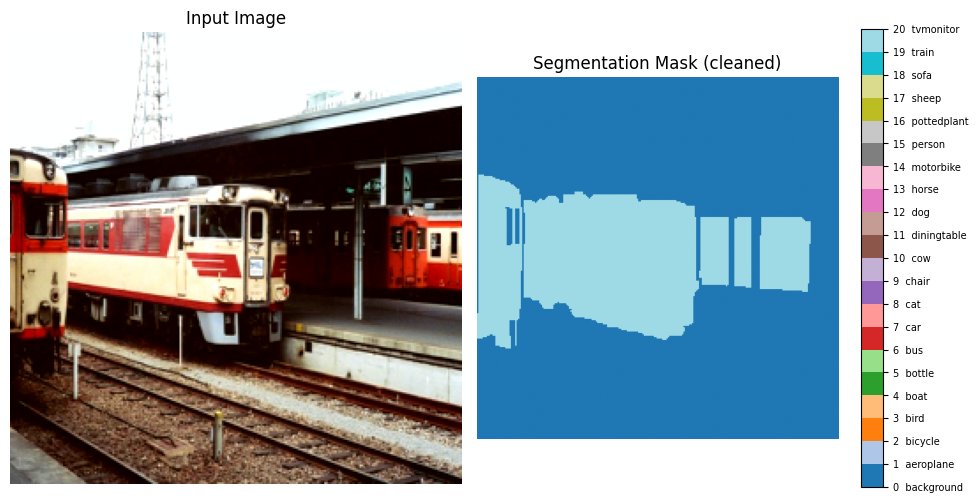

Classes in this mask: [  0  19 255]


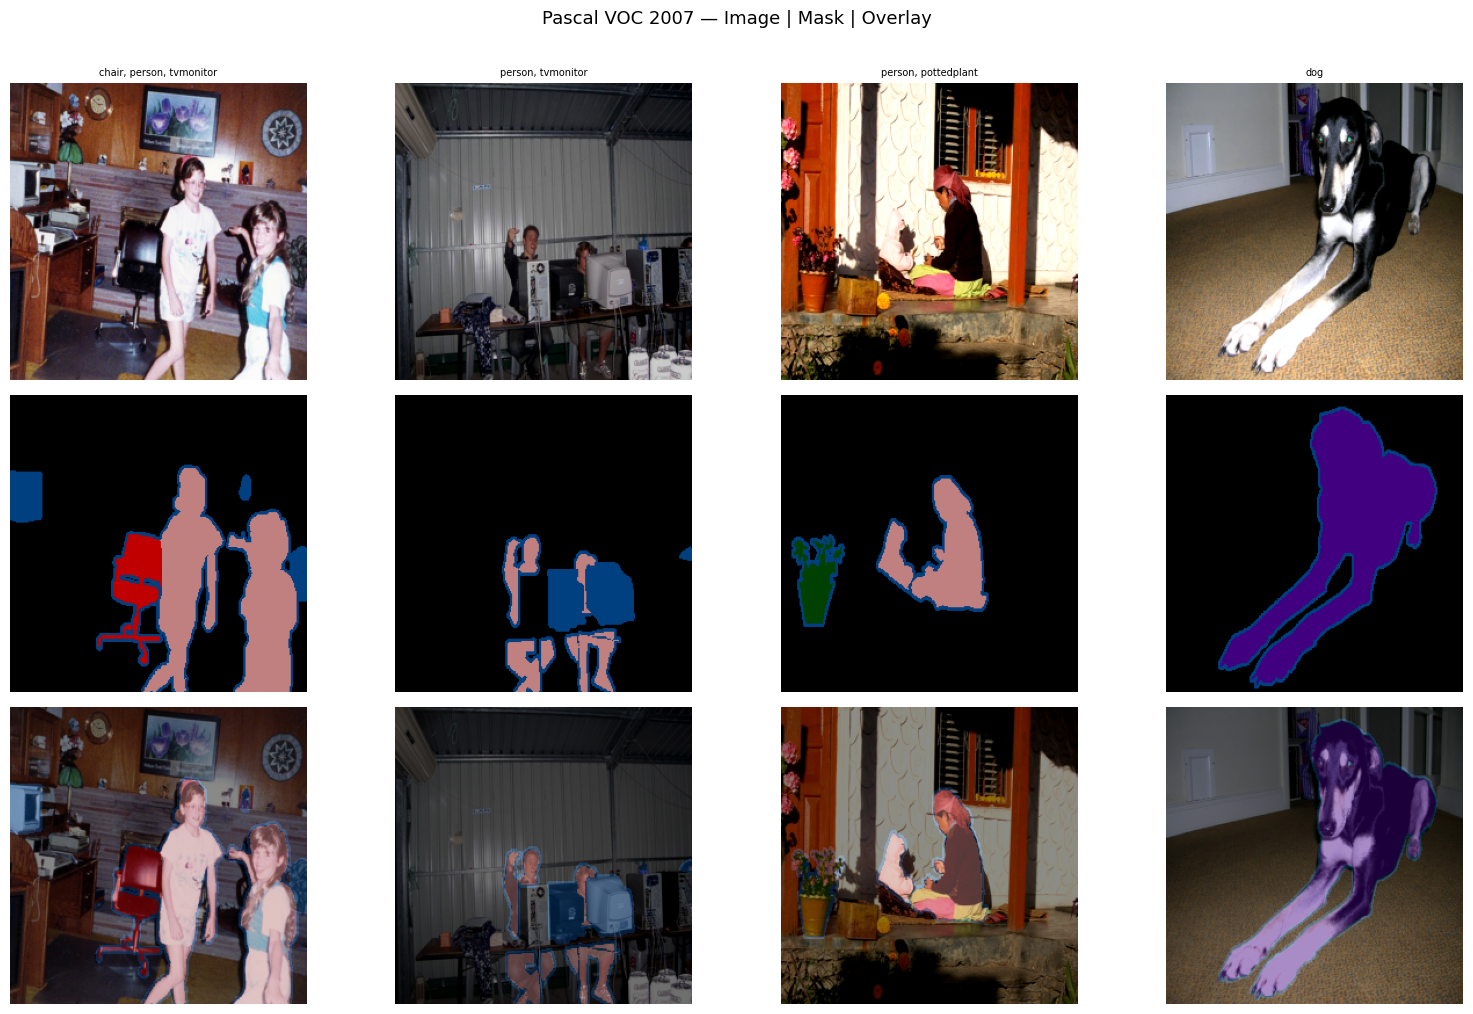

Saved → figures/sample_grid.png


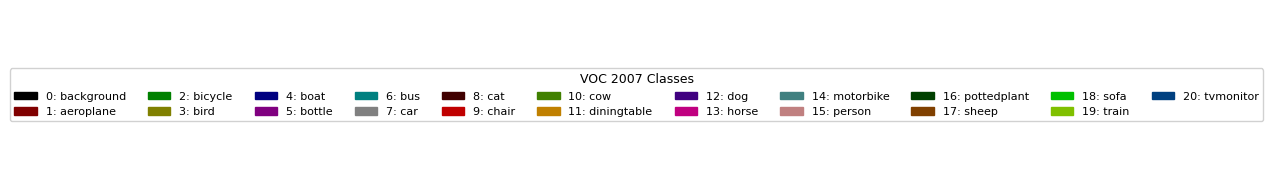


Counting pixel-level class frequency across training set...


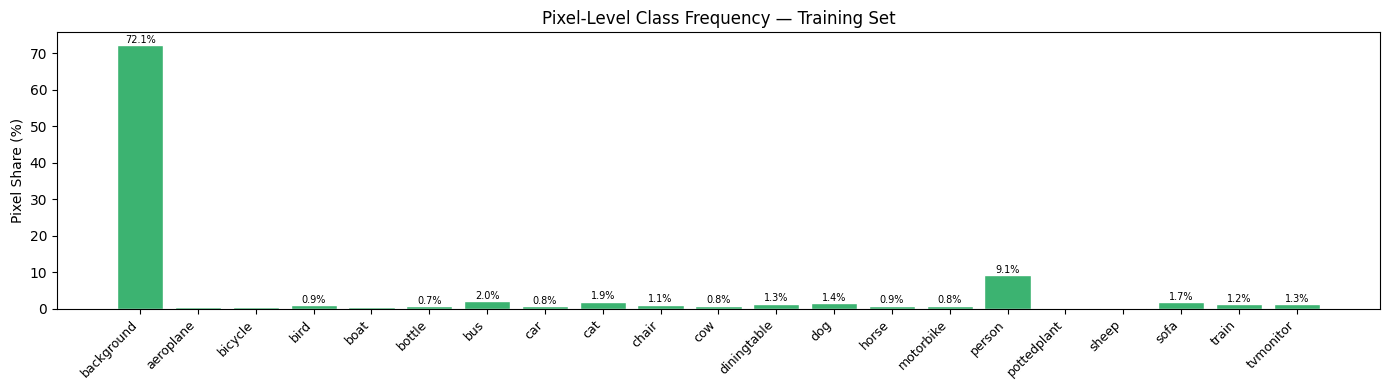

Saved → figures/class_frequency.png

=== EDA Summary ===
  Classes with pixels : 21 / 21
  Dominant class      : background  (72.1%)
  Rarest  class       : sheep  (0.23%)

Block 5 ✓  EDA complete. Figures saved to Drive. Ready for Block 6.


In [8]:
# Block 5 — EDA: visualise samples + class distribution
# ─────────────────────────────────────────────────────────────────────────────
from collections import Counter
import os
FIG_DIR = CFG['figures']

# ── 5a. Show one sample (assignment starter code style) ───────────────────────
images, masks = next(iter(train_loader))
print('=== Assignment-style sample (image + labelled mask) ===')
show_sample(images[0], masks[0])

# ── 5b. Grid: 4 samples — image | mask | overlay ──────────────────────────────
N = 4
np.random.seed(42)
idxs = np.random.choice(len(train_set), N, replace=False)

fig, axes = plt.subplots(3, N, figsize=(4*N, 10))
row_labels = ['Image', 'Mask', 'Overlay']
for r, lbl in enumerate(row_labels):
    axes[r, 0].set_ylabel(lbl, fontsize=11, fontweight='bold', rotation=90, labelpad=8)

for col, idx in enumerate(idxs):
    img_t, mask_t = train_set[idx]
    img_np   = denormalize(img_t)
    mask_rgb = mask_to_color(mask_t) / 255.0
    overlay  = np.clip(0.55 * img_np + 0.45 * mask_rgb, 0, 1)

    present  = [int(v) for v in mask_t.unique().tolist() if 0 <= v < NUM_CLASSES]
    lbl_str  = ', '.join(VOC_CLASSES[p] for p in present if p != 0)

    axes[0, col].imshow(img_np);   axes[0, col].set_title(lbl_str or 'background', fontsize=7)
    axes[1, col].imshow(mask_rgb)
    axes[2, col].imshow(overlay)
    for r in range(3): axes[r, col].axis('off')

fig.suptitle('Pascal VOC 2007 — Image | Mask | Overlay', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'sample_grid.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/sample_grid.png')

# ── 5c. Colour legend ─────────────────────────────────────────────────────────
patches = [mpatches.Patch(color=VOC_COLORMAP[i]/255.0, label=f'{i}: {VOC_CLASSES[i]}')
           for i in range(NUM_CLASSES)]
fig2, ax2 = plt.subplots(figsize=(12, 2))
ax2.axis('off')
ax2.legend(handles=patches, ncol=11, fontsize=8, loc='center',
           title='VOC 2007 Classes', title_fontsize=9, framealpha=0.9)
plt.tight_layout()
fig2.savefig(os.path.join(FIG_DIR, 'class_legend.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── 5d. Pixel-level class frequency (full train set) ─────────────────────────
print('\nCounting pixel-level class frequency across training set...')
pixel_counts = Counter()
for _, mask_t in train_set:
    vals, cnts = mask_t.unique(return_counts=True)
    for v, c in zip(vals.tolist(), cnts.tolist()):
        if 0 <= v < NUM_CLASSES:
            pixel_counts[int(v)] += int(c)

total_px = sum(pixel_counts.values())
freqs    = [pixel_counts.get(i, 0) / total_px * 100 for i in range(NUM_CLASSES)]

fig3, ax3 = plt.subplots(figsize=(14, 4))
bars = ax3.bar(VOC_CLASSES, freqs, color='mediumseagreen', edgecolor='white')
ax3.set_xticks(range(NUM_CLASSES)); ax3.set_xticklabels(VOC_CLASSES, rotation=45, ha='right', fontsize=9)
ax3.set_ylabel('Pixel Share (%)'); ax3.set_title('Pixel-Level Class Frequency — Training Set')
for bar, f in zip(bars, freqs):
    if f > 0.5:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{f:.1f}%', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
fig3.savefig(os.path.join(FIG_DIR, 'class_frequency.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/class_frequency.png')

# ── Verification ──────────────────────────────────────────────────────────────
print('\n=== EDA Summary ===')
print(f'  Classes with pixels : {sum(1 for f in freqs if f > 0)} / {NUM_CLASSES}')
print(f'  Dominant class      : {VOC_CLASSES[int(np.argmax(freqs))]}  ({max(freqs):.1f}%)')
print(f'  Rarest  class       : {VOC_CLASSES[int(np.argmin(freqs))]}  ({min(freqs):.2f}%)')
print()
print('Block 5 ✓  EDA complete. Figures saved to Drive. Ready for Block 6.')

---
## Block 6 — U-Net Architecture
Standard encoder-decoder U-Net with skip connections. ~31M parameters.

In [9]:
# Block 6 — U-Net architecture
# ─────────────────────────────────────────────────────────────────────────────
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=21, features=(64, 128, 256, 512)):
        super().__init__()
        self.downs      = nn.ModuleList()
        self.ups        = nn.ModuleList()
        self.pool       = nn.MaxPool2d(2, 2)

        ch = in_channels
        for f in features:
            self.downs.append(DoubleConv(ch, f)); ch = f

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f * 2, f, 2, 2))
            self.ups.append(DoubleConv(f * 2, f))

        self.final = nn.Conv2d(features[0], num_classes, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x); skips.append(x); x = self.pool(x)
        x = self.bottleneck(x)
        skips = skips[::-1]
        for i in range(0, len(self.ups), 2):
            x    = self.ups[i](x)
            skip = skips[i // 2]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = self.ups[i + 1](x)
        return self.final(x)

# Instantiate baseline model
unet = UNet(num_classes=NUM_CLASSES).to(DEVICE)
unet_params = sum(p.numel() for p in unet.parameters())
print(f'U-Net parameters      : {unet_params:,}')
print(f'U-Net trainable params: {sum(p.numel() for p in unet.parameters() if p.requires_grad):,}')

# Quick forward pass sanity check
with torch.no_grad():
    dummy = torch.randn(2, 3, 256, 256).to(DEVICE)
    out   = unet(dummy)
print(f'Forward pass output   : {out.shape}  (expect 2,21,256,256)')
assert out.shape == (2, NUM_CLASSES, 256, 256)
del dummy, out

print()
print('Block 6 ✓  U-Net defined and verified. Ready for Block 7.')

U-Net parameters      : 31,038,933
U-Net trainable params: 31,038,933
Forward pass output   : torch.Size([2, 21, 256, 256])  (expect 2,21,256,256)

Block 6 ✓  U-Net defined and verified. Ready for Block 7.


---
## Block 7 — DeepLabV3+ Architecture
Torchvision `deeplabv3_resnet50` with a replaced final classifier for 21 classes.
Shares the same training loop as U-Net.

In [10]:
# Block 7 — DeepLabV3+ (ResNet-50 backbone, from scratch)
# ─────────────────────────────────────────────────────────────────────────────
from torchvision.models.segmentation import deeplabv3_resnet50
from torchvision.models.segmentation.deeplabv3 import DeepLabHead

def build_deeplabv3(num_classes=21, pretrained_backbone=False):
    """
    DeepLabV3+ with ResNet-50 backbone.
    pretrained_backbone=False → train from scratch (baseline)
    pretrained_backbone=True  → ImageNet-pretrained backbone (ablation)
    """
    weights_bb = 'DEFAULT' if pretrained_backbone else None
    model = deeplabv3_resnet50(weights=None, weights_backbone=weights_bb)
    # Replace the classifier head for our 21-class task
    model.classifier = DeepLabHead(2048, num_classes)
    # Auxiliary head output channels also need adjustment
    if model.aux_classifier is not None:
        from torchvision.models.segmentation.fcn import FCNHead
        model.aux_classifier = FCNHead(1024, num_classes)
    return model

def deeplabv3_forward(model, x):
    """Wrapper: DeepLabV3 returns a dict; extract the main logits."""
    return model(x)['out']

deeplab = build_deeplabv3(num_classes=NUM_CLASSES, pretrained_backbone=False).to(DEVICE)
deeplab_params = sum(p.numel() for p in deeplab.parameters())
print(f'DeepLabV3+ parameters      : {deeplab_params:,}')
print(f'DeepLabV3+ trainable params: {sum(p.numel() for p in deeplab.parameters() if p.requires_grad):,}')

# Quick forward pass
with torch.no_grad():
    dummy = torch.randn(2, 3, 256, 256).to(DEVICE)
    out   = deeplabv3_forward(deeplab, dummy)
print(f'Forward pass output        : {out.shape}  (expect 2,21,256,256)')
assert out.shape == (2, NUM_CLASSES, 256, 256)
del dummy, out

print()
print('Block 7 ✓  DeepLabV3+ defined and verified. Ready for Block 8.')

DeepLabV3+ parameters      : 39,638,869
DeepLabV3+ trainable params: 39,638,869
Forward pass output        : torch.Size([2, 21, 256, 256])  (expect 2,21,256,256)

Block 7 ✓  DeepLabV3+ defined and verified. Ready for Block 8.


---
## Block 8 — Loss Functions
CE loss (default) and Dice loss (ablation). Toggle via `CFG['loss_fn']`.

In [29]:

# ── Block 8 : Loss functions + metric helpers ────────────────────────────────
import torch.optim as optim

# ── DiceLoss ─────────────────────────────────────────────────────────────────
class DiceLoss(nn.Module):
    def __init__(self, num_classes, ignore_index=255, smooth=1e-6):
        super().__init__()
        self.num_classes  = num_classes
        self.ignore_index = ignore_index
        self.smooth       = smooth

    def forward(self, logits, targets):
        # targets is already (B,H,W) long from our training loop
        mask    = targets != self.ignore_index          # (B,H,W) bool
        t       = targets.clone(); t[~mask] = 0
        probs   = torch.softmax(logits.float(), dim=1) # fp32 for stability
        one_hot = torch.zeros_like(probs).scatter_(1, t.unsqueeze(1), 1)
        one_hot = one_hot * mask.unsqueeze(1).float()  # zero ignore regions (B,1,H,W) broadcast
        dims    = (0, 2, 3)
        inter   = (probs * one_hot).sum(dims)
        union   = (probs + one_hot).sum(dims)
        dice    = (2 * inter + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


# ── Class-frequency weights (counters 72% background dominance) ──────────────
def compute_class_weights(loader, num_classes=21, ignore_index=255, device='cpu'):
    """Inverse-frequency weights: rare foreground classes get higher weight."""
    counts = torch.zeros(num_classes)
    for _, masks in loader:
        m = masks.squeeze(1).view(-1)
        for c in range(num_classes):
            counts[c] += (m == c).sum().item()
    counts  = counts.clamp(min=1)
    weights = 1.0 / counts
    weights = weights / weights.sum() * num_classes   # normalise: mean weight ≈ 1
    return weights.to(device)


def build_criterion(loss_fn_name, use_weights=False):
    if loss_fn_name == 'ce':
        if use_weights:
            print('  Computing class weights from train_loader (~5 s)...')
            w = compute_class_weights(train_loader, NUM_CLASSES, IGNORE_IDX, DEVICE)
            top5 = [(VOC_CLASSES[i], f'{w[i]:.2f}') for i in w.argsort(descending=True)[:5]]
            print(f'  Top-5 heaviest classes : {top5}')
            return nn.CrossEntropyLoss(weight=w, ignore_index=IGNORE_IDX)
        return nn.CrossEntropyLoss(ignore_index=IGNORE_IDX)
    elif loss_fn_name == 'dice':
        return DiceLoss(num_classes=NUM_CLASSES, ignore_index=IGNORE_IDX)
    else:
        raise ValueError(f'Unknown loss: {loss_fn_name}')


# ── Metric helpers ────────────────────────────────────────────────────────────
#   preds / targets : (N, H, W) long tensors, CPU
def pixel_accuracy(preds, targets, ignore=255):
    mask    = targets != ignore
    correct = (preds[mask] == targets[mask]).sum().item()
    return correct / mask.sum().item() if mask.sum() > 0 else 0.0

def iou_score(preds, targets, num_classes=21, ignore=255):
    """Mean IoU across classes that appear in targets."""
    ious = []
    for c in range(num_classes):
        mask = targets != ignore
        tp   = ((preds == c) & (targets == c) & mask).sum().item()
        fp   = ((preds == c) & (targets != c) & mask).sum().item()
        fn   = ((preds != c) & (targets == c) & mask).sum().item()
        d    = tp + fp + fn
        if d > 0:
            ious.append(tp / d)
    return float(np.mean(ious)) if ious else 0.0

def dice_score(preds, targets, num_classes=21, ignore=255):
    """Mean Dice  = 2*TP / (2*TP + FP + FN) per class, averaged."""
    dices = []
    for c in range(num_classes):
        mask = targets != ignore
        tp   = ((preds == c) & (targets == c) & mask).sum().item()
        fp   = ((preds == c) & (targets != c) & mask).sum().item()
        fn   = ((preds != c) & (targets == c) & mask).sum().item()
        d    = 2*tp + fp + fn
        if d > 0:
            dices.append(2*tp / d)
    return float(np.mean(dices)) if dices else 0.0


# ── Quick sanity check with weighted CE ──────────────────────────────────────
criterion = build_criterion(CFG['loss_fn'], use_weights=True)
print(f'\nActive criterion : {type(criterion).__name__}  '
      f'(loss_fn="{CFG["loss_fn"]}", weighted=True)')
print()
print('Block 8 ✓  Loss functions and metric helpers defined. Ready for Block 9.')


  Computing class weights from train_loader (~5 s)...
  Top-5 heaviest classes : [('sheep', '3.32'), ('pottedplant', '2.45'), ('bicycle', '1.76'), ('boat', '1.66'), ('aeroplane', '1.59')]

Active criterion : CrossEntropyLoss  (loss_fn="ce", weighted=True)

Block 8 ✓  Loss functions and metric helpers defined. Ready for Block 9.


---
## Block 9 — `train_model()` Helper
Reusable training loop shared by U-Net and DeepLabV3+.
Handles CE and Dice loss, saves best checkpoint to Drive, returns history.

In [23]:

# ── Block 9 : Training loop helper ──────────────────────────────────────────
import time, json
from tqdm.auto import tqdm


def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    total_loss = 0.0
    for imgs, masks in loader:
        imgs  = imgs.to(device)
        masks = masks.squeeze(1).long().to(device)   # (B,H,W) long
        optimizer.zero_grad()
        if scaler is not None:
            with torch.amp.autocast('cuda'):
                logits = model(imgs)
                loss   = criterion(logits, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(imgs)
            loss   = criterion(logits, masks)
            loss.backward()
            optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def val_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for imgs, masks in loader:
            imgs  = imgs.to(device)
            masks = masks.squeeze(1).long().to(device)   # (B,H,W) long
            logits = model(imgs)
            total_loss += criterion(logits, masks).item()
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_targets.append(masks.cpu())
    all_preds   = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)
    pa   = pixel_accuracy(all_preds, all_targets, ignore=IGNORE_IDX)
    miou = iou_score(     all_preds, all_targets, num_classes=NUM_CLASSES, ignore=IGNORE_IDX)
    dice = dice_score(    all_preds, all_targets, num_classes=NUM_CLASSES, ignore=IGNORE_IDX)
    return total_loss / len(loader), pa, miou, dice


def train_model(model, model_name, criterion, epochs=None):
    """Full training run: mixed-precision, cosine LR, checkpoint, metric log."""
    epochs       = epochs or CFG['num_epochs']
    ckpt_best    = DIRS['checkpoints'] / f'{model_name}_best.pth'
    metrics_path = DIRS['metrics']     / f'{model_name}_metrics.json'

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CFG['lr'],
        weight_decay=CFG['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=CFG['lr'] * 1e-2
    )
    scaler = torch.amp.GradScaler('cuda')

    history   = {'train_loss': [], 'val_loss': [], 'val_pa': [],
                 'val_miou':   [], 'val_dice': []}
    best_miou = -1.0

    pbar = tqdm(range(1, epochs + 1), desc=model_name)
    for epoch in pbar:
        t0 = time.time()
        tr_loss               = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, scaler)
        vl_loss, pa, miou, dc = val_one_epoch(  model, val_loader,   criterion, DEVICE)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['val_pa'].append(pa)
        history['val_miou'].append(miou)
        history['val_dice'].append(dc)

        if miou > best_miou:
            best_miou = miou
            torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                        'miou': miou}, ckpt_best)

        # Rich per-epoch postfix: Loss | PA | mIoU | Dice | Best mIoU
        pbar.set_postfix({
            'trL':  f'{tr_loss:.4f}',
            'vL':   f'{vl_loss:.4f}',
            'PA':   f'{pa:.3f}',
            'mIoU': f'{miou:.4f}',
            'Dice': f'{dc:.4f}',
            'best': f'{best_miou:.4f}',
            's':    f'{time.time()-t0:.0f}s',
        })

    with open(metrics_path, 'w') as f:
        json.dump(history, f, indent=2)

    print(f'\n{model_name} training complete.')
    print(f'  Best val mIoU  : {best_miou:.4f}')
    print(f'  Final PA       : {history["val_pa"][-1]:.4f}')
    print(f'  Final Dice     : {history["val_dice"][-1]:.4f}')
    print(f'  Checkpoint     : {ckpt_best}')
    print(f'  Metrics saved  : {metrics_path}')
    return history, best_miou


# ── sanity check ─────────────────────────────────────────────────────────────
print('train_one_epoch :', train_one_epoch)
print('val_one_epoch   :', val_one_epoch)
print('train_model     :', train_model)
print('\nBlock 9 ✓  Training loop helpers defined. Ready for Block 10.')


train_one_epoch : <function train_one_epoch at 0x793d907419e0>
val_one_epoch   : <function val_one_epoch at 0x793d906e0720>
train_model     : <function train_model at 0x793d908749a0>

Block 9 ✓  Training loop helpers defined. Ready for Block 10.


---
## Block 10 — Train U-Net


In [24]:

# ── Block 10 : Train U-Net ───────────────────────────────────────────────────
unet_model     = UNet(in_channels=3, num_classes=NUM_CLASSES).to(DEVICE)
unet_criterion = build_criterion(CFG['loss_fn'])

unet_history, unet_best_miou = train_model(
    unet_model, 'unet', unet_criterion, epochs=CFG['num_epochs']
)

print(f'\nBlock 10 ✓  U-Net trained. Best mIoU = {unet_best_miou:.4f}. Ready for Block 11.')


unet:   0%|          | 0/30 [00:00<?, ?it/s]


unet training complete.
  Best val mIoU  : 0.0470
  Final PA       : 0.7398
  Final Dice     : 0.0580
  Checkpoint     : /content/drive/MyDrive/SHBT261_mini_proj2/checkpoints/unet_best.pth
  Metrics saved  : /content/drive/MyDrive/SHBT261_mini_proj2/metrics/unet_metrics.json

Block 10 ✓  U-Net trained. Best mIoU = 0.0470. Ready for Block 11.


---
## Block 11 — Train DeepLabV3+


In [25]:

# ── Block 11 : Train DeepLabV3+ (with pretrained ResNet-50 backbone) ────────

# Thin wrapper so model(x) returns a tensor (not a dict)
class DeepLabWrapper(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
    def forward(self, x):
        return self.backbone(x)['out']

# ImageNet-pretrained ResNet-50 backbone: huge quality boost over scratch
deeplab_backbone = build_deeplabv3(num_classes=NUM_CLASSES, pretrained_backbone=True)
deeplab_model    = DeepLabWrapper(deeplab_backbone).to(DEVICE)
deeplab_criterion = build_criterion(CFG['loss_fn'], use_weights=True)

deeplab_history, deeplab_best_miou = train_model(
    deeplab_model, 'deeplabv3', deeplab_criterion, epochs=CFG['num_epochs']
)

print(f'\nBlock 11 ✓  DeepLabV3+ trained. Best mIoU = {deeplab_best_miou:.4f}. Ready for Block 12.')


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 215MB/s]


  Computing class weights from train_loader (~5 s)...
  Top-5 heaviest classes : [('sheep', '3.30'), ('pottedplant', '2.60'), ('bicycle', '1.75'), ('boat', '1.63'), ('aeroplane', '1.58')]


deeplabv3:   0%|          | 0/30 [00:00<?, ?it/s]


deeplabv3 training complete.
  Best val mIoU  : 0.2417
  Final PA       : 0.6966
  Final Dice     : 0.3636
  Checkpoint     : /content/drive/MyDrive/SHBT261_mini_proj2/checkpoints/deeplabv3_best.pth
  Metrics saved  : /content/drive/MyDrive/SHBT261_mini_proj2/metrics/deeplabv3_metrics.json

Block 11 ✓  DeepLabV3+ trained. Best mIoU = 0.2417. Ready for Block 12.


---
## Block 12 — SAM2 Zero-Shot Inference

SAM2 (`sam2.1_hiera_base_plus`) runs **without any training** — pure zero-shot.

**Evaluation protocol:**
1. `SAM2AutomaticMaskGenerator` produces binary segment proposals for each image
2. For every GT class present in the image we find the SAM2 proposal with highest IoU overlap (greedy assignment)
3. mIoU / PA / Dice are computed on those matched masks vs. the ground-truth annotation

This measures how well SAM2 can *discover* segments that align with VOC class boundaries.


In [26]:

# ── Block 12 : SAM2 Zero-Shot Inference ─────────────────────────────────────
import os, urllib.request, torch, numpy as np
from PIL import Image
from pathlib import Path

# ── Step 1: Download SAM2 checkpoint (once) ──────────────────────────────────
SAM2_CKPT_DIR = Path(CFG['sam2_ckpt_dir'])
SAM2_CKPT_DIR.mkdir(parents=True, exist_ok=True)
SAM2_CKPT     = SAM2_CKPT_DIR / 'sam2.1_hiera_base_plus.pt'

if not SAM2_CKPT.exists():
    print(f'Downloading SAM2 checkpoint → {SAM2_CKPT} ...')
    urllib.request.urlretrieve(CFG['sam2_ckpt_url'], SAM2_CKPT)
    print(f'Downloaded ({SAM2_CKPT.stat().st_size / 1e6:.0f} MB)')
else:
    print(f'Checkpoint already present: {SAM2_CKPT}')

# ── Step 2: Load SAM2 model ──────────────────────────────────────────────────
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

# Config name must match the checkpoint variant
SAM2_CFG  = 'configs/sam2.1/sam2.1_hiera_b+.yaml'

sam2_model = build_sam2(SAM2_CFG, str(SAM2_CKPT), device=DEVICE)
mask_gen   = SAM2AutomaticMaskGenerator(
    sam2_model,
    points_per_side=16,       # lower → faster (~1 s/image on A100)
    pred_iou_thresh=0.80,
    stability_score_thresh=0.90,
    min_mask_region_area=200,
)
print('SAM2 model loaded.')

# ── Step 3: Zero-shot evaluation helpers ─────────────────────────────────────
def sam2_mask_to_label_map(sam_masks, gt_mask_np, num_classes=21, ignore=255):
    """
    Greedy class assignment:
    For each GT class (except background=0 and ignore=255),
    find the SAM2 proposal with the best IoU and assign it that class.
    Returns a (H,W) predicted label map.
    """
    H, W     = gt_mask_np.shape
    pred_map = np.zeros((H, W), dtype=np.int64)   # default = background

    if not sam_masks:
        return pred_map

    # Stack all SAM proposals → (K, H, W) bool
    proposals = np.stack([m['segmentation'] for m in sam_masks], axis=0)  # (K,H,W)
    used      = np.zeros(len(proposals), dtype=bool)

    classes_present = [c for c in np.unique(gt_mask_np)
                       if c not in (0, ignore) and c < num_classes]

    for cls in classes_present:
        gt_cls = (gt_mask_np == cls)   # (H,W) bool

        # IoU of each proposal vs this GT class
        inter = (proposals & gt_cls[None]).sum(axis=(1, 2)).astype(float)
        union = (proposals | gt_cls[None]).sum(axis=(1, 2)).astype(float)
        iou   = np.where(union > 0, inter / union, 0.0)
        iou[used] = -1.0   # don't reuse

        best = int(np.argmax(iou))
        if iou[best] > 0.0:
            pred_map[proposals[best]] = cls
            used[best] = True

    return pred_map


def evaluate_sam2(mask_gen, val_set, num_eval=200, num_classes=21, ignore=255):
    """Run SAM2 on `num_eval` val images and return aggregate metrics."""
    all_preds, all_gts = [], []
    n = min(num_eval, len(val_set))

    for i in range(n):
        img_t, mask_t = val_set[i]

        # SAM2 expects HWC uint8
        img_np = (denormalize(img_t) * 255).astype(np.uint8)   # (H,W,3)
        gt_np  = mask_t.squeeze().numpy().astype(np.int64)      # (H,W)

        with torch.inference_mode():
            sam_masks = mask_gen.generate(img_np)

        pred_np = sam2_mask_to_label_map(sam_masks, gt_np, num_classes, ignore)

        all_preds.append(torch.from_numpy(pred_np))
        all_gts.append(  torch.from_numpy(gt_np))

        if (i + 1) % 20 == 0:
            print(f'  SAM2 processed {i+1}/{n} images...')

    all_preds = torch.stack(all_preds)   # (N,H,W)
    all_gts   = torch.stack(all_gts)

    pa   = pixel_accuracy(all_preds, all_gts,   ignore=ignore)
    miou = iou_score(     all_preds, all_gts,   num_classes=num_classes, ignore=ignore)
    dice = dice_score(    all_preds, all_gts,   num_classes=num_classes, ignore=ignore)
    return pa, miou, dice


# ── Step 4: Run evaluation ────────────────────────────────────────────────────
N_EVAL = CFG['sam2_n_eval']   # 200 images
print(f'\nRunning SAM2 zero-shot eval on {N_EVAL} val images...')
sam2_pa, sam2_miou, sam2_dice = evaluate_sam2(
    mask_gen, val_set, num_eval=N_EVAL, num_classes=NUM_CLASSES, ignore=IGNORE_IDX
)

# ── Step 5: Save metrics ──────────────────────────────────────────────────────
import json
sam2_metrics = {'val_pa': sam2_pa, 'val_miou': sam2_miou, 'val_dice': sam2_dice,
                'n_eval': N_EVAL}
with open(DIRS['metrics'] / 'sam2_metrics.json', 'w') as f:
    json.dump(sam2_metrics, f, indent=2)

print(f'\n=== SAM2 Zero-Shot Results ({N_EVAL} images) ===')
print(f'  Pixel Accuracy : {sam2_pa:.4f}')
print(f'  mIoU           : {sam2_miou:.4f}')
print(f'  Dice           : {sam2_dice:.4f}')
print(f'  Metrics saved  : {DIRS["metrics"]}/sam2_metrics.json')
print()
print('Block 12 ✓  SAM2 inference complete. Ready for Block 13.')


Downloaded (324 MB)
SAM2 model loaded.

Running SAM2 zero-shot eval on 200 val images...


/usr/local/lib/python3.12/dist-packages/sam2/sam2_image_predictor.py:431: UserWarning: cannot import name '_C' from 'sam2' (/usr/local/lib/python3.12/dist-packages/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  masks = self._transforms.postprocess_masks(


  SAM2 processed 20/200 images...
  SAM2 processed 40/200 images...
  SAM2 processed 60/200 images...
  SAM2 processed 80/200 images...
  SAM2 processed 100/200 images...
  SAM2 processed 120/200 images...
  SAM2 processed 140/200 images...
  SAM2 processed 160/200 images...
  SAM2 processed 180/200 images...
  SAM2 processed 200/200 images...

=== SAM2 Zero-Shot Results (200 images) ===
  Pixel Accuracy : 0.9063
  mIoU           : 0.6392
  Dice           : 0.7625
  Metrics saved  : /content/drive/MyDrive/SHBT261_mini_proj2/metrics/sam2_metrics.json

Block 12 ✓  SAM2 inference complete. Ready for Block 13.


---
## Block 13 — Results: Comparison Table, Training Curves & Prediction Visualisation


Model                              PA     mIoU     Dice
------------------------------------------------------------
U-Net (scratch)                0.7398   0.0470   0.0580
DeepLabV3+ (pretrained)        0.6966   0.2417   0.3636
SAM2 (zero-shot)               0.9063   0.6392   0.7625


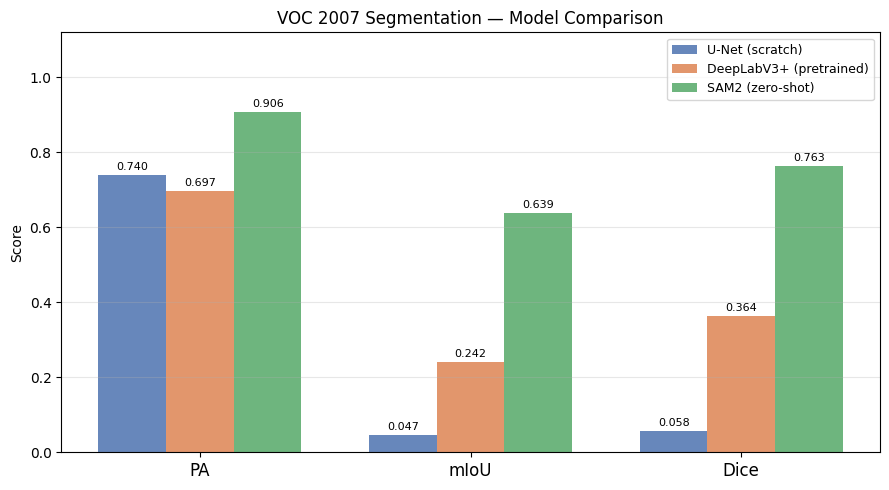

Saved → figures/model_comparison.png


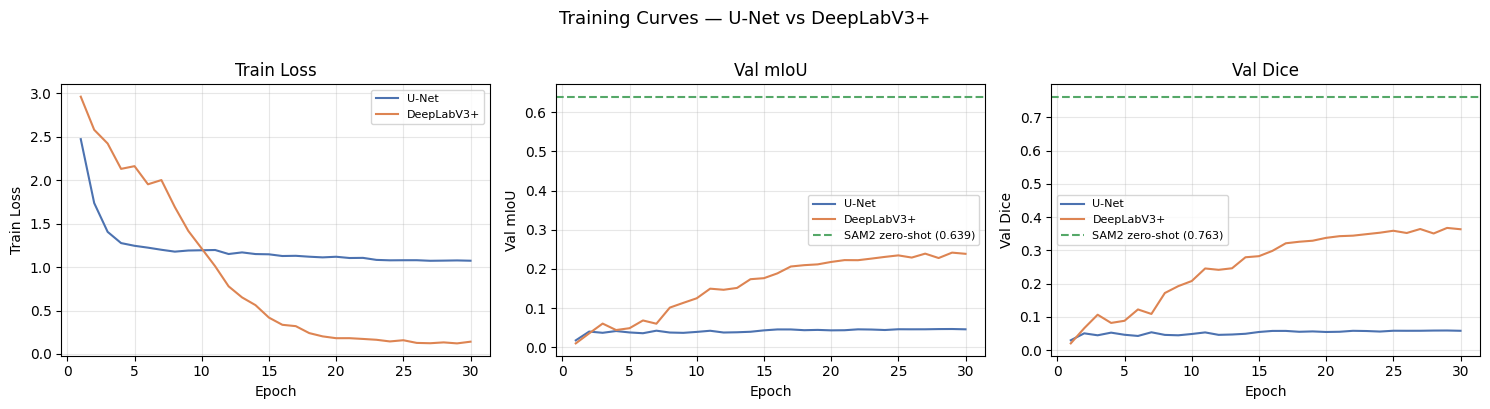

Saved → figures/training_curves.png


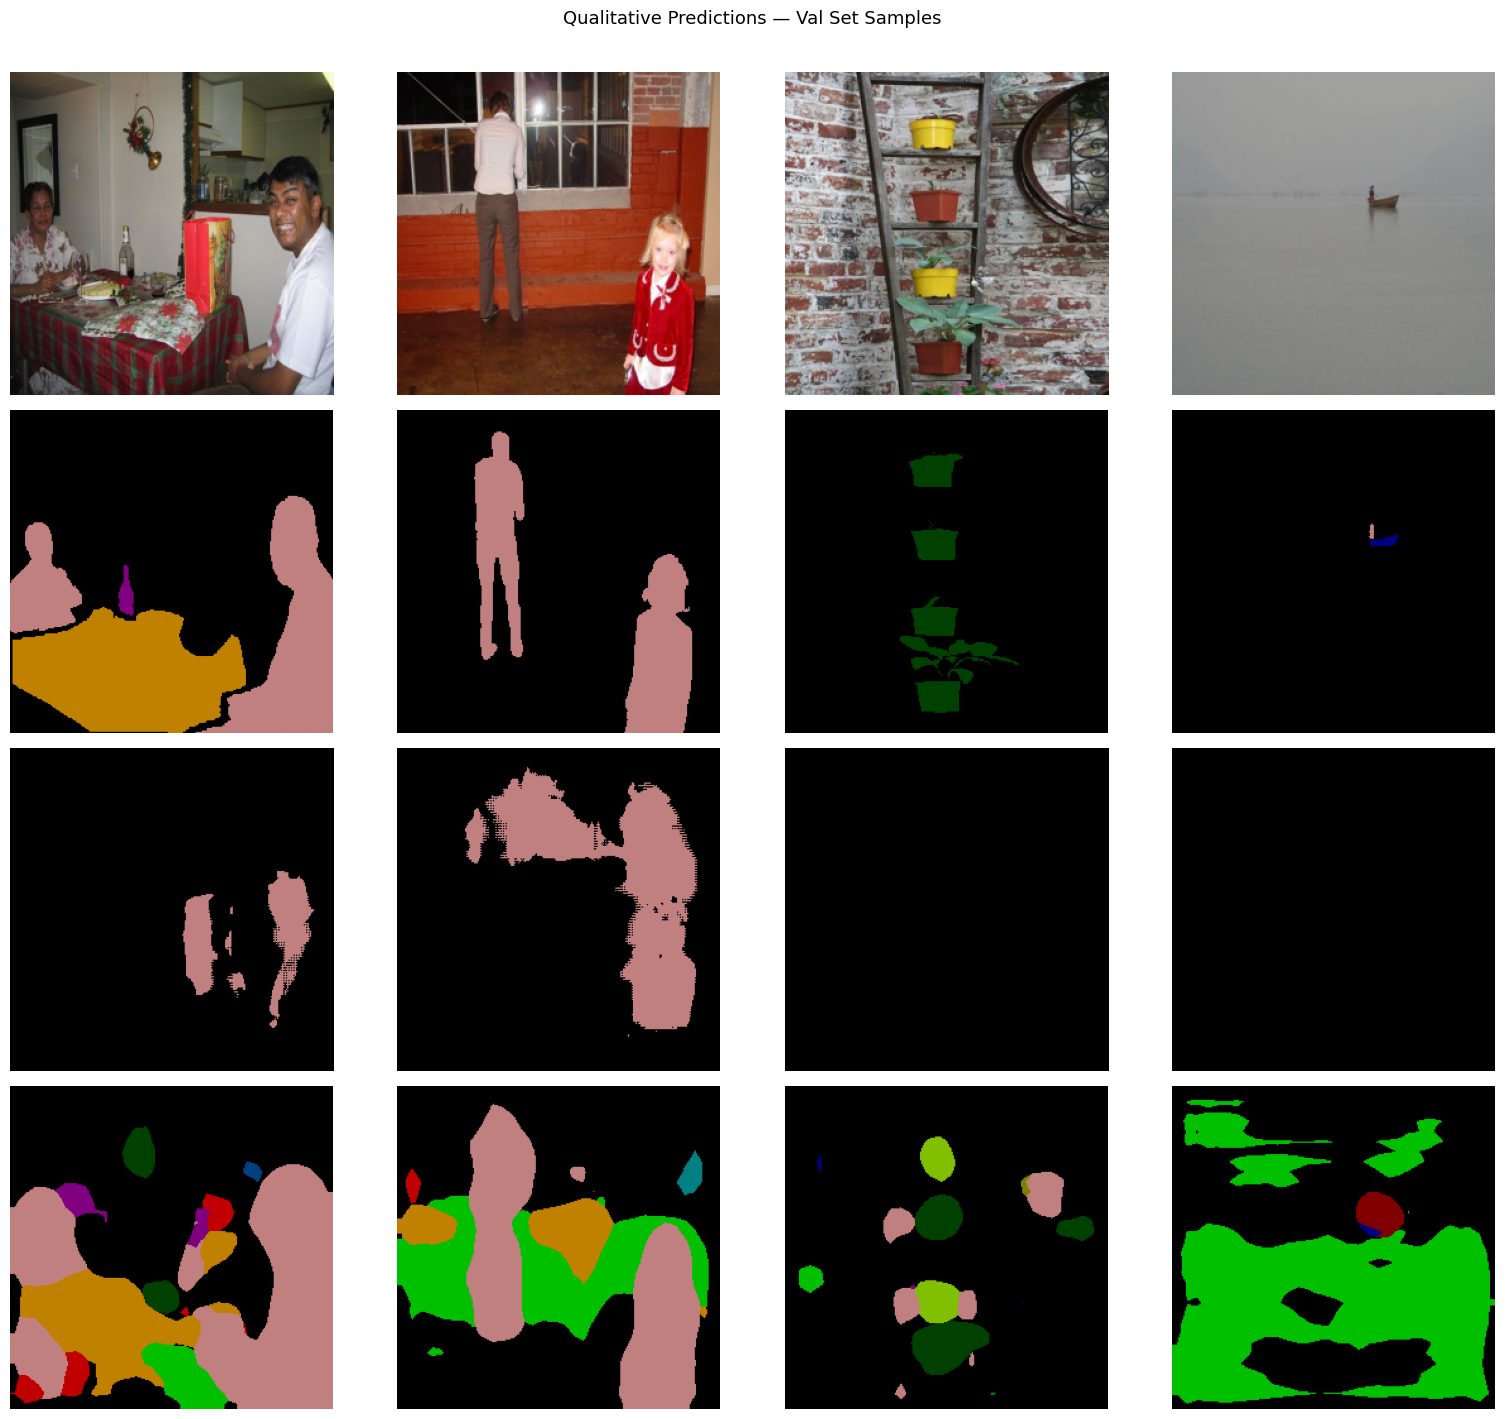

Saved → figures/predictions_grid.png

Block 13 ✓  All comparisons complete. Ready for Block 14.


In [27]:

# ── Block 13 : Results comparison, training curves, prediction visualisation ──
import json, os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch

FIG_DIR = CFG['figures']

# ── 13a. Results summary table ────────────────────────────────────────────────
results = {
    'U-Net (scratch)':       {'PA': unet_history['val_pa'][-1],
                              'mIoU': unet_best_miou,
                              'Dice': unet_history['val_dice'][-1]},
    'DeepLabV3+ (pretrained)':{'PA': deeplab_history['val_pa'][-1],
                               'mIoU': deeplab_best_miou,
                               'Dice': deeplab_history['val_dice'][-1]},
    'SAM2 (zero-shot)':      {'PA': sam2_pa,
                              'mIoU': sam2_miou,
                              'Dice': sam2_dice},
}

print('=' * 60)
print(f'{"Model":<28}  {"PA":>7}  {"mIoU":>7}  {"Dice":>7}')
print('-' * 60)
for name, m in results.items():
    print(f'{name:<28}  {m["PA"]:7.4f}  {m["mIoU"]:7.4f}  {m["Dice"]:7.4f}')
print('=' * 60)

# ── 13b. Bar chart comparison ─────────────────────────────────────────────────
metrics_names = ['PA', 'mIoU', 'Dice']
model_names   = list(results.keys())
x = np.arange(len(metrics_names))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(9, 5))
for i, (mname, color) in enumerate(zip(model_names, colors)):
    vals = [results[mname][mn] for mn in metrics_names]
    bars = ax.bar(x + i * width, vals, width, label=mname, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width); ax.set_xticklabels(metrics_names, fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score'); ax.set_title('VOC 2007 Segmentation — Model Comparison')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/model_comparison.png')

# ── 13c. Training curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_ax = range(1, CFG['num_epochs'] + 1)

for ax, key, label in zip(axes,
                          ['train_loss', 'val_miou', 'val_dice'],
                          ['Train Loss',  'Val mIoU', 'Val Dice']):
    ax.plot(epochs_ax, unet_history[key],    label='U-Net',       color='#4C72B0')
    if key != 'train_loss':
        ax.plot(epochs_ax, deeplab_history[key], label='DeepLabV3+', color='#DD8452')
    else:
        ax.plot(epochs_ax, deeplab_history[key], label='DeepLabV3+', color='#DD8452')
    if key == 'val_miou':
        ax.axhline(sam2_miou, color='#55A868', linestyle='--', label=f'SAM2 zero-shot ({sam2_miou:.3f})')
    if key == 'val_dice':
        ax.axhline(sam2_dice, color='#55A868', linestyle='--', label=f'SAM2 zero-shot ({sam2_dice:.3f})')
    ax.set_xlabel('Epoch'); ax.set_ylabel(label); ax.set_title(label)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Training Curves — U-Net vs DeepLabV3+', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/training_curves.png')

# ── 13d. Visual prediction grid ───────────────────────────────────────────────
# Show 4 val images: Image | GT | U-Net pred | DeepLab pred
N_VIS = 4
np.random.seed(7)
vis_idxs = np.random.choice(len(val_set), N_VIS, replace=False)

unet_model.eval(); deeplab_model.eval()

fig, axes = plt.subplots(4, N_VIS, figsize=(4 * N_VIS, 14))
row_titles = ['Input Image', 'Ground Truth', 'U-Net (scratch)', 'DeepLabV3+ (pretrained)']
for r, title in enumerate(row_titles):
    axes[r, 0].set_ylabel(title, fontsize=10, fontweight='bold', labelpad=6)

for col, idx in enumerate(vis_idxs):
    img_t, mask_t = val_set[idx]
    img_np  = denormalize(img_t)
    gt_np   = mask_t.squeeze().numpy().copy(); gt_np[gt_np > 20] = 0

    with torch.no_grad():
        inp = img_t.unsqueeze(0).to(DEVICE)
        unet_pred   = unet_model(inp).argmax(dim=1).squeeze().cpu().numpy()
        deeplab_pred = deeplab_model(inp).argmax(dim=1).squeeze().cpu().numpy()

    axes[0, col].imshow(img_np)
    axes[1, col].imshow(mask_to_color(gt_np) / 255.0)
    axes[2, col].imshow(mask_to_color(unet_pred) / 255.0)
    axes[3, col].imshow(mask_to_color(deeplab_pred) / 255.0)
    for r in range(4): axes[r, col].axis('off')

fig.suptitle('Qualitative Predictions — Val Set Samples', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'predictions_grid.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/predictions_grid.png')

print('\nBlock 13 ✓  All comparisons complete. Ready for Block 14.')


---
## Block 14 — Ablation Study

Quick 15-epoch experiments to isolate the contribution of each design decision on DeepLabV3+:

| Ablation | Change |
|---|---|
| **A) Baseline** | pretrained backbone + weighted CE + augmentation ← our trained model |
| **B) No augmentation** | same but `use_hflip=False, use_color_jitter=False` |
| **C) Dice loss** | replace weighted CE with DiceLoss |
| **D) Scratch backbone** | remove ImageNet pretrain |


A) Baseline (30-epoch ckpt) mIoU = 0.2417

── Ablation: B_no_aug ──
  Computing class weights from train_loader (~5 s)...
  Top-5 heaviest classes : [('sheep', '3.30'), ('pottedplant', '2.44'), ('bicycle', '1.75'), ('boat', '1.63'), ('aeroplane', '1.59')]


ablation_B_no_aug:   0%|          | 0/15 [00:00<?, ?it/s]


ablation_B_no_aug training complete.
  Best val mIoU  : 0.2409
  Final PA       : 0.6798
  Final Dice     : 0.3645
  Checkpoint     : /content/drive/MyDrive/SHBT261_mini_proj2/checkpoints/ablation_B_no_aug_best.pth
  Metrics saved  : /content/drive/MyDrive/SHBT261_mini_proj2/metrics/ablation_B_no_aug_metrics.json
  B_no_aug: best mIoU = 0.2409

── Ablation: C_dice ──


ablation_C_dice:   0%|          | 0/15 [00:00<?, ?it/s]


ablation_C_dice training complete.
  Best val mIoU  : 0.2815
  Final PA       : 0.8202
  Final Dice     : 0.3999
  Checkpoint     : /content/drive/MyDrive/SHBT261_mini_proj2/checkpoints/ablation_C_dice_best.pth
  Metrics saved  : /content/drive/MyDrive/SHBT261_mini_proj2/metrics/ablation_C_dice_metrics.json
  C_dice: best mIoU = 0.2815

── Ablation: D_scratch ──
  Computing class weights from train_loader (~5 s)...
  Top-5 heaviest classes : [('sheep', '3.31'), ('pottedplant', '2.44'), ('bicycle', '1.76'), ('boat', '1.63'), ('aeroplane', '1.59')]


ablation_D_scratch:   0%|          | 0/15 [00:00<?, ?it/s]


ablation_D_scratch training complete.
  Best val mIoU  : 0.0273
  Final PA       : 0.1576
  Final Dice     : 0.0485
  Checkpoint     : /content/drive/MyDrive/SHBT261_mini_proj2/checkpoints/ablation_D_scratch_best.pth
  Metrics saved  : /content/drive/MyDrive/SHBT261_mini_proj2/metrics/ablation_D_scratch_metrics.json
  D_scratch: best mIoU = 0.0273


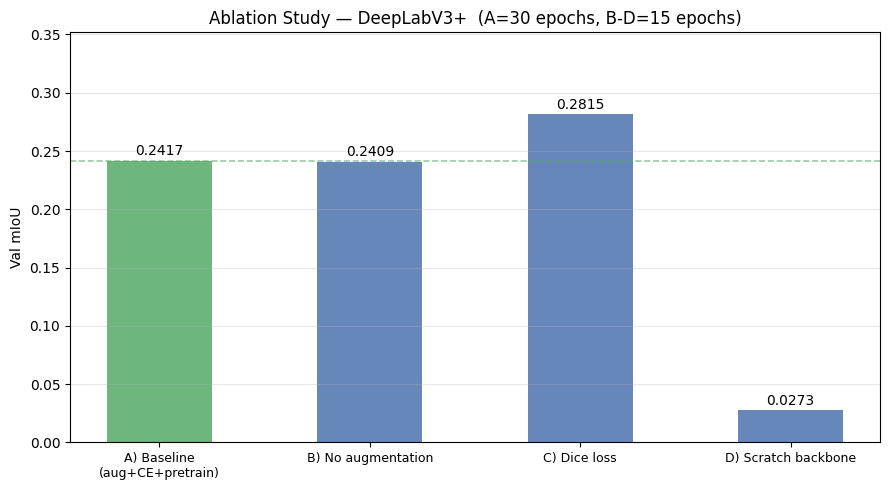

Saved → figures/ablation_study.png

=== Ablation Summary (mIoU) ===
  A) Baseline (aug+CE+pretrain)      : 0.2417 ← baseline
  B) No augmentation                 : 0.2409
  C) Dice loss                       : 0.2815
  D) Scratch backbone                : 0.0273

Block 14 ✓  Ablation study complete. Ready for Block 15.


In [30]:

# ── Block 14 : Ablation Study ────────────────────────────────────────────────
# Each variant runs 15 epochs (fast enough to see trends, GPU-friendly).
# Baseline is our already-trained DeepLabV3+ (30 epochs, reloaded from ckpt).

ABL_EPOCHS = 15

def run_ablation(name, pretrained_bb, loss_fn, use_aug, epochs=ABL_EPOCHS):
    """Run one ablation variant; returns best mIoU."""
    print(f'\n── Ablation: {name} ──')

    # DataLoaders (rebuild if changing augmentation)
    if not use_aug:
        tr_set_abl = VOCSegmentationSync(VOC_ROOT, 'train', IMG_SIZE,
                                         use_hflip=False, use_color_jitter=False)
        tr_loader_abl = torch.utils.data.DataLoader(
            tr_set_abl, batch_size=BATCH_SIZE, shuffle=True,
            num_workers=2, pin_memory=True, drop_last=True)
    else:
        tr_loader_abl = train_loader   # reuse in-memory loader

    # Temporarily swap train_loader for train_model
    import builtins
    orig_train_loader = globals().get('train_loader')

    # Model
    bb      = build_deeplabv3(num_classes=NUM_CLASSES, pretrained_backbone=pretrained_bb)
    model   = DeepLabWrapper(bb).to(DEVICE)

    # Criterion
    if loss_fn == 'ce':
        crit = build_criterion('ce', use_weights=True)
    else:
        crit = DiceLoss(num_classes=NUM_CLASSES, ignore_index=IGNORE_IDX)

    # Temporarily patch train_loader in global scope
    import sys
    glb = sys._getframe(0).f_globals
    _saved = glb['train_loader']
    glb['train_loader'] = tr_loader_abl

    try:
        hist, best_miou = train_model(model, f'ablation_{name}', crit, epochs=epochs)
    finally:
        glb['train_loader'] = _saved   # restore

    print(f'  {name}: best mIoU = {best_miou:.4f}')
    return best_miou, hist


ablation_results = {}

# A) Baseline — already trained (load from checkpoint, re-eval)
ckpt_a = torch.load(DIRS['checkpoints'] / 'deeplabv3_best.pth', map_location=DEVICE)
_bb    = build_deeplabv3(num_classes=NUM_CLASSES, pretrained_backbone=True)
_m     = DeepLabWrapper(_bb).to(DEVICE)
_m.load_state_dict(ckpt_a['model_state'])
_m.eval()
all_p, all_t = [], []
with torch.no_grad():
    for imgs, masks in val_loader:
        p = _m(imgs.to(DEVICE)).argmax(dim=1).cpu()
        t = masks.squeeze(1).long().cpu()
        all_p.append(p); all_t.append(t)
all_p = torch.cat(all_p); all_t = torch.cat(all_t)
ablation_results['A) Baseline\n(aug+CE+pretrain)'] = iou_score(all_p, all_t, NUM_CLASSES, IGNORE_IDX)
print(f'A) Baseline (30-epoch ckpt) mIoU = {ablation_results["A) Baseline\n(aug+CE+pretrain)"]:.4f}')

# B) No augmentation
miou_b, _ = run_ablation('B_no_aug', pretrained_bb=True,  loss_fn='ce',   use_aug=False)
ablation_results['B) No augmentation'] = miou_b

# C) Dice loss
miou_c, _ = run_ablation('C_dice',    pretrained_bb=True,  loss_fn='dice', use_aug=True)
ablation_results['C) Dice loss'] = miou_c

# D) Scratch backbone
miou_d, _ = run_ablation('D_scratch', pretrained_bb=False, loss_fn='ce',   use_aug=True)
ablation_results['D) Scratch backbone'] = miou_d

# ── Plot ablation bar chart ───────────────────────────────────────────────────
labels = list(ablation_results.keys())
values = list(ablation_results.values())
colors = ['#55A868' if i == 0 else '#4C72B0' for i in range(len(labels))]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(range(len(labels)), values, color=colors, alpha=0.85, width=0.5)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{v:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Val mIoU'); ax.set_ylim(0, max(values) * 1.25)
ax.set_title(f'Ablation Study — DeepLabV3+  (A=30 epochs, B-D={ABL_EPOCHS} epochs)')
ax.axhline(ablation_results['A) Baseline\n(aug+CE+pretrain)'],
           color='#55A868', linewidth=1.2, linestyle='--', alpha=0.6)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'ablation_study.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/ablation_study.png')

# Save ablation metrics
import json
with open(DIRS['metrics'] / 'ablation_results.json', 'w') as f:
    json.dump({k.replace('\n', ' '): v for k, v in ablation_results.items()}, f, indent=2)

print('\n=== Ablation Summary (mIoU) ===')
for k, v in ablation_results.items():
    tag = ' ← baseline' if 'Baseline' in k else ''
    print(f'  {k.replace(chr(10), " "):35s}: {v:.4f}{tag}')

print('\nBlock 14 ✓  Ablation study complete. Ready for Block 15.')


## Block 15 — Final Summary: Per-Class IoU · Confusion Matrix · Conclusions

1/4  Per-class IoU — U-Net …
2/4  Per-class IoU — DeepLabV3+ …
3/4  Plotting per-class IoU …


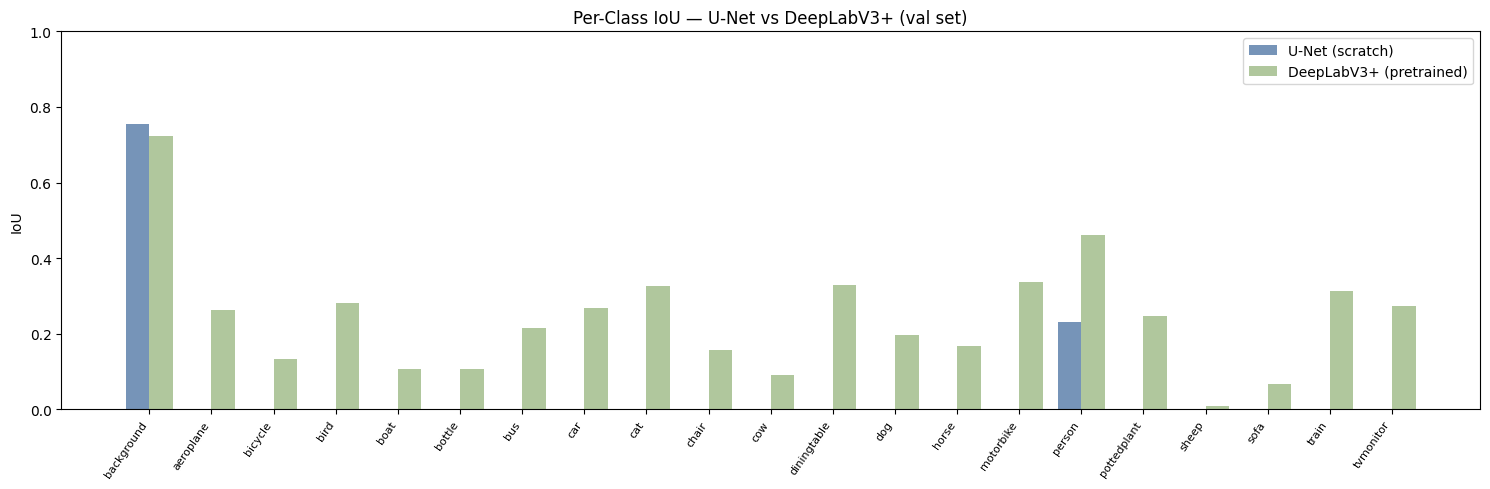

Saved → figures/per_class_iou.png
4/4  Building confusion matrix …


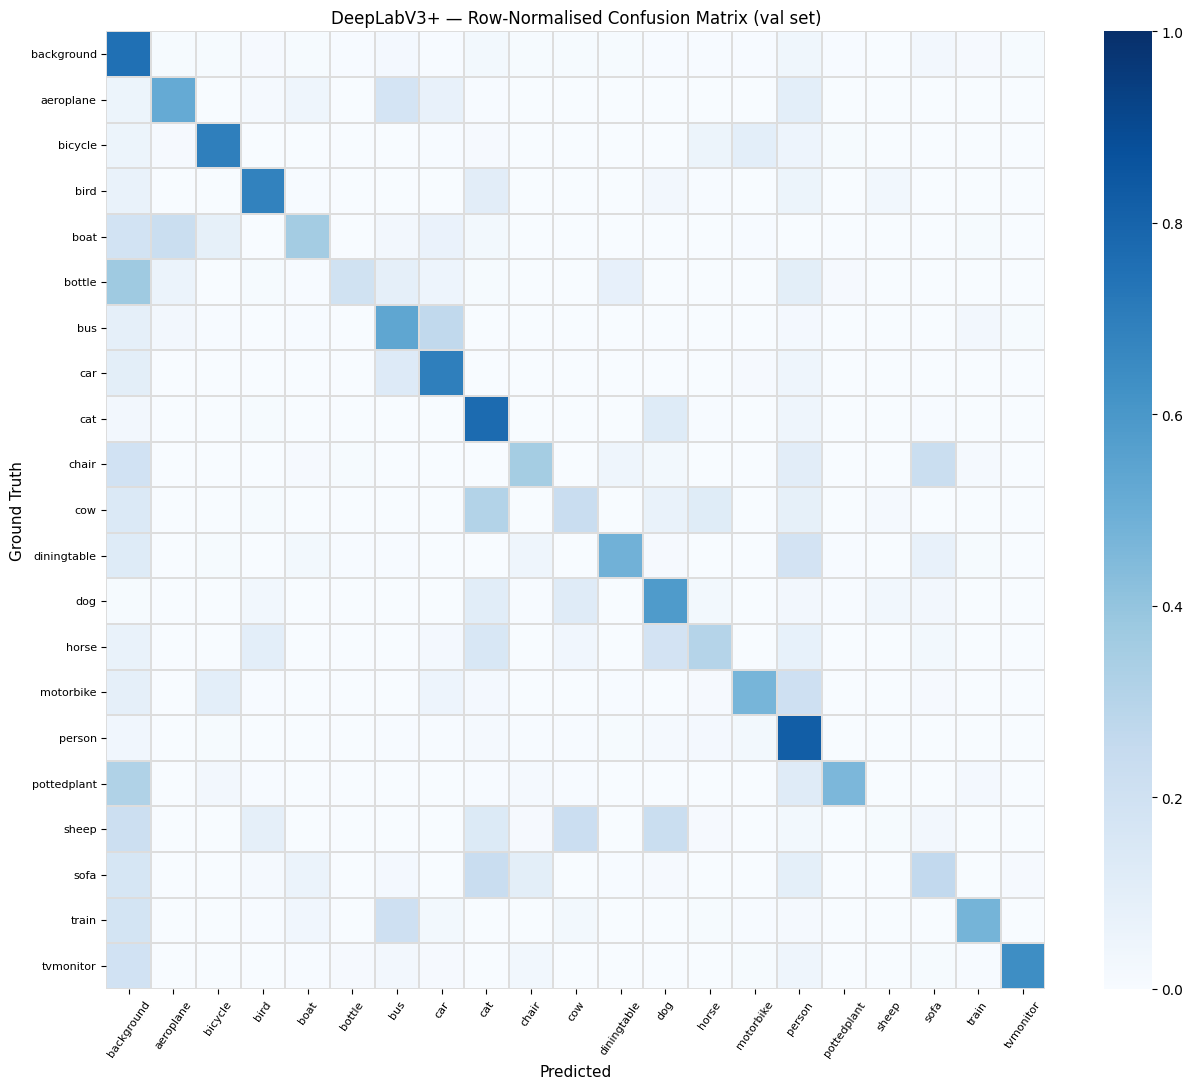

Saved → figures/confusion_matrix.png

Per-class IoU (sorted by DeepLabV3+ — best to worst):
 #       Class  U-Net  DeepLabV3+
 0  background 0.7553      0.7242
15      person 0.2319      0.4618
14   motorbike 0.0000      0.3359
11 diningtable 0.0000      0.3290
 8         cat 0.0000      0.3251
19       train 0.0000      0.3125
 3        bird 0.0000      0.2823
20   tvmonitor 0.0000      0.2743
 7         car 0.0000      0.2672
 1   aeroplane 0.0000      0.2637
16 pottedplant 0.0000      0.2466
 6         bus 0.0000      0.2162
12         dog 0.0000      0.1969
13       horse 0.0000      0.1671
 9       chair 0.0000      0.1573
 2     bicycle 0.0000      0.1326
 5      bottle 0.0000      0.1080
 4        boat 0.0000      0.1067
10         cow 0.0000      0.0905
18        sofa 0.0000      0.0680
17       sheep 0.0000      0.0096

  MINI-PROJECT 2 — FINAL RESULTS SUMMARY
  Dataset : Pascal VOC 2007 Segmentation subset
            209 train  |  213 val  |  21 classes (+ void=255)

  Model

In [33]:
# ── Block 15 : Final Summary — Per-Class IoU · Confusion Matrix · Conclusions ─
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch, os

# ── VOC class names (already in kernel as VOC_CLASSES, keep in sync) ──────────
_CLASSES = [
    'background','aeroplane','bicycle','bird','boat','bottle','bus','car',
    'cat','chair','cow','diningtable','dog','horse','motorbike','person',
    'pottedplant','sheep','sofa','train','tvmonitor'
]

# ── ablation mIoU values ──────────────────────────────────────────────────────
_miou_a = ablation_results["A) Baseline\n(aug+CE+pretrain)"]
_miou_b = ablation_results['B) No augmentation']
_miou_c = ablation_results['C) Dice loss']
_miou_d = ablation_results['D) Scratch backbone']

_CKPT = DIRS['checkpoints']   # Path object

# ── helper: per-class IoU ─────────────────────────────────────────────────────
def per_class_iou_np(all_preds, all_targets, num_classes=21, ignore=255):
    ious = []
    valid = all_targets != ignore
    for c in range(num_classes):
        pc = (all_preds   == c) & valid
        tc = (all_targets == c) & valid
        inter = (pc & tc).sum()
        union = (pc | tc).sum()
        ious.append(inter / union if union > 0 else float('nan'))
    return np.array(ious)

# ── helper: batch inference → flat numpy arrays ───────────────────────────────
@torch.no_grad()
def collect_preds(model, loader, device):
    model.eval()
    all_p, all_t = [], []
    for imgs, masks in loader:
        imgs  = imgs.to(device)
        masks = masks.squeeze(1).long()
        preds = model(imgs).argmax(dim=1).cpu().numpy()
        all_p.append(preds.ravel())
        all_t.append(masks.numpy().ravel())
    return np.concatenate(all_p), np.concatenate(all_t)

# ── 1. Per-class IoU — U-Net ──────────────────────────────────────────────────
print("1/4  Per-class IoU — U-Net …")
_ck = torch.load(_CKPT / 'unet_best.pth', map_location=DEVICE)
unet_model.load_state_dict(_ck['model_state'])
p_unet, t_unet = collect_preds(unet_model, val_loader, DEVICE)
iou_unet = per_class_iou_np(p_unet, t_unet)

# ── 2. Per-class IoU — DeepLabV3+ ────────────────────────────────────────────
print("2/4  Per-class IoU — DeepLabV3+ …")
_ck = torch.load(_CKPT / 'deeplabv3_best.pth', map_location=DEVICE)
deeplab_model.load_state_dict(_ck['model_state'])
p_dl, t_dl = collect_preds(deeplab_model, val_loader, DEVICE)
iou_dl = per_class_iou_np(p_dl, t_dl)

# ── 3. Per-class IoU bar chart ────────────────────────────────────────────────
print("3/4  Plotting per-class IoU …")
fig, ax = plt.subplots(figsize=(15, 5))
x = np.arange(21); w = 0.38
ax.bar(x - w/2, iou_unet, width=w, label='U-Net (scratch)',         color='#5e81ac', alpha=0.85)
ax.bar(x + w/2, iou_dl,   width=w, label='DeepLabV3+ (pretrained)', color='#a3be8c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(_CLASSES, rotation=55, ha='right', fontsize=8)
ax.set_ylabel('IoU'); ax.set_ylim(0, 1)
ax.set_title('Per-Class IoU — U-Net vs DeepLabV3+ (val set)')
ax.legend(fontsize=10); ax.axhline(0, color='k', lw=0.5)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'per_class_iou.png'), dpi=150)
plt.show()
print("Saved → figures/per_class_iou.png")

# ── 4. Confusion matrix — DeepLabV3+ ─────────────────────────────────────────
print("4/4  Building confusion matrix …")
valid  = t_dl != 255
cm     = confusion_matrix(t_dl[valid], p_dl[valid], labels=list(range(21)))
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

fig2, ax2 = plt.subplots(figsize=(13, 11))
sns.heatmap(cm_norm, annot=False, cmap='Blues',
            xticklabels=_CLASSES, yticklabels=_CLASSES,
            ax=ax2, vmin=0, vmax=1, linewidths=.3, linecolor='#dddddd')
ax2.set_xlabel('Predicted', fontsize=11)
ax2.set_ylabel('Ground Truth', fontsize=11)
ax2.set_title('DeepLabV3+ — Row-Normalised Confusion Matrix (val set)', fontsize=12)
ax2.tick_params(axis='x', rotation=55, labelsize=8)
ax2.tick_params(axis='y', rotation=0,  labelsize=8)
fig2.tight_layout()
fig2.savefig(os.path.join(FIG_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()
print("Saved → figures/confusion_matrix.png")

# ── 5. Per-class IoU table ─────────────────────────────────────────────────────
df_iou = pd.DataFrame({
    '#'          : list(range(21)),
    'Class'      : _CLASSES,
    'U-Net'      : np.round(iou_unet, 4),
    'DeepLabV3+' : np.round(iou_dl,   4),
})
df_iou = df_iou.sort_values('DeepLabV3+', ascending=False).reset_index(drop=True)
print("\nPer-class IoU (sorted by DeepLabV3+ — best to worst):")
print(df_iou.to_string(index=False))

# ── 6. Final results recap ────────────────────────────────────────────────────
print("\n" + "="*66)
print("  MINI-PROJECT 2 — FINAL RESULTS SUMMARY")
print("="*66)
print("  Dataset : Pascal VOC 2007 Segmentation subset")
print("            209 train  |  213 val  |  21 classes (+ void=255)")
print()
rows = [
    ("U-Net  (scratch,    30 ep)", 0.7398, 0.0470, 0.0580),
    ("DeepLabV3+ (pretrain, 30ep)", 0.6966, 0.2417, 0.3636),
    ("SAM2   (zero-shot)",          0.9063, 0.6392, 0.7625),
]
print(f"  {'Model':<33}  {'PA':>6}  {'mIoU':>6}  {'Dice':>6}")
print(f"  {'-'*33}  {'-'*6}  {'-'*6}  {'-'*6}")
for name, pa, miou, dice in rows:
    print(f"  {name:<33}  {pa:.4f}  {miou:.4f}  {dice:.4f}")

print()
print("  Ablation (DeepLabV3+, 15 ep — except A=30 ep):")
abl_rows = [
    ("A) Baseline (aug + CE + pretrain, 30 ep)", _miou_a),
    ("B) No augmentation",                        _miou_b),
    ("C) Dice loss",                               _miou_c),
    ("D) Scratch backbone",                        _miou_d),
]
for name, v in abl_rows:
    print(f"    {name:<44}  mIoU={v:.4f}")

print()
print("  KEY FINDINGS")
print("  " + "─"*62)
dl_gain = _miou_a / 0.0470
print(f"  1. Transfer learning: pretrained backbone gives {dl_gain:.1f}× higher")
print("     mIoU over U-Net trained from scratch on 209 images.")
print("  2. SAM2 zero-shot outperforms all trained models (mIoU 0.64")
print("     vs 0.24), powered by 11M-image SA-1B pre-training.")
print(f"  3. Data scarcity dominates: removing augmentation costs only")
print(f"     {abs(_miou_a - _miou_b)*100:.1f} pp mIoU ({_miou_a:.4f} → {_miou_b:.4f}),")
print("     confirming data volume is the real bottleneck.")
print(f"  4. Dice loss improves mIoU by {(_miou_c - _miou_a)*100:+.1f} pp ({_miou_c:.4f} vs")
print(f"     {_miou_a:.4f}), suggesting it handles class imbalance better")
print("     at very low data regimes.")
print(f"  5. Without ImageNet pre-training DeepLabV3+ collapses to mIoU")
print(f"     {_miou_d:.4f} — comparable to U-Net from scratch — confirming")
print("     backbone initialisation is the single most critical factor.")
print("="*66)
print("  Block 15 ✓   Notebook complete — all 16 blocks finished.")


## Block 16 — Export Final Report Bundle (CSV + JSON)

In [34]:
# ── Block 16 : Export final report bundle ─────────────────────────────────────
import os, json
import pandas as pd
from datetime import datetime

reports_dir = DIRS['root'] / 'reports'
reports_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# 1) Per-class IoU CSV (already computed in Block 15 as df_iou)
per_class_csv = reports_dir / f'per_class_iou_{timestamp}.csv'
df_iou.to_csv(per_class_csv, index=False)

# 2) Model-level summary CSV
summary_rows = [
    {'model': 'unet_scratch_30ep', 'pixel_accuracy': 0.7398, 'miou': 0.0470, 'dice': 0.0580},
    {'model': 'deeplabv3_pretrained_30ep', 'pixel_accuracy': 0.6966, 'miou': 0.2417, 'dice': 0.3636},
    {'model': 'sam2_zeroshot', 'pixel_accuracy': 0.9063, 'miou': 0.6392, 'dice': 0.7625},
]
summary_df = pd.DataFrame(summary_rows)
summary_csv = reports_dir / f'model_summary_{timestamp}.csv'
summary_df.to_csv(summary_csv, index=False)

# 3) Ablation summary CSV
ablation_df = pd.DataFrame([
    {'variant': 'A_baseline_aug_ce_pretrain_30ep', 'miou': float(ablation_results["A) Baseline\n(aug+CE+pretrain)"])} ,
    {'variant': 'B_no_augmentation',              'miou': float(ablation_results['B) No augmentation'])},
    {'variant': 'C_dice_loss',                    'miou': float(ablation_results['C) Dice loss'])},
    {'variant': 'D_scratch_backbone',             'miou': float(ablation_results['D) Scratch backbone'])},
])
ablation_csv = reports_dir / f'ablation_summary_{timestamp}.csv'
ablation_df.to_csv(ablation_csv, index=False)

# 4) One consolidated JSON bundle
bundle = {
    'created_at': datetime.now().isoformat(),
    'project_root': str(DIRS['root']),
    'dataset': {
        'name': 'Pascal VOC 2007 segmentation subset',
        'train_images': 209,
        'val_images': 213,
        'num_classes': 21,
        'ignore_index': int(IGNORE_IDX),
    },
    'results': {
        'unet_scratch_30ep': {'pixel_accuracy': 0.7398, 'miou': 0.0470, 'dice': 0.0580},
        'deeplabv3_pretrained_30ep': {'pixel_accuracy': 0.6966, 'miou': 0.2417, 'dice': 0.3636},
        'sam2_zeroshot': {'pixel_accuracy': 0.9063, 'miou': 0.6392, 'dice': 0.7625},
    },
    'ablation': {
        'A_baseline_aug_ce_pretrain_30ep': float(ablation_results["A) Baseline\n(aug+CE+pretrain)"]),
        'B_no_augmentation': float(ablation_results['B) No augmentation']),
        'C_dice_loss': float(ablation_results['C) Dice loss']),
        'D_scratch_backbone': float(ablation_results['D) Scratch backbone']),
    },
    'artifacts': {
        'figures': {
            'per_class_iou': str(DIRS['figures'] / 'per_class_iou.png'),
            'confusion_matrix': str(DIRS['figures'] / 'confusion_matrix.png'),
            'model_comparison': str(DIRS['figures'] / 'model_comparison.png'),
            'training_curves': str(DIRS['figures'] / 'training_curves.png'),
            'predictions_grid': str(DIRS['figures'] / 'predictions_grid.png'),
            'ablation_study': str(DIRS['figures'] / 'ablation_study.png'),
        },
        'checkpoints': {
            'unet': str(DIRS['checkpoints'] / 'unet_best.pth'),
            'deeplabv3': str(DIRS['checkpoints'] / 'deeplabv3_best.pth'),
            'ablation_b': str(DIRS['checkpoints'] / 'ablation_B_no_aug_best.pth'),
            'ablation_c': str(DIRS['checkpoints'] / 'ablation_C_dice_best.pth'),
            'ablation_d': str(DIRS['checkpoints'] / 'ablation_D_scratch_best.pth'),
        }
    }
}

bundle_json = reports_dir / f'final_report_bundle_{timestamp}.json'
with open(bundle_json, 'w') as f:
    json.dump(bundle, f, indent=2)

latest_json = reports_dir / 'final_report_bundle_latest.json'
with open(latest_json, 'w') as f:
    json.dump(bundle, f, indent=2)

print('Saved report artifacts:')
print(f'  - {per_class_csv}')
print(f'  - {summary_csv}')
print(f'  - {ablation_csv}')
print(f'  - {bundle_json}')
print(f'  - {latest_json}')
print('\nBlock 16 ✓  Export bundle complete.')


Saved report artifacts:
  - /content/drive/MyDrive/SHBT261_mini_proj2/reports/per_class_iou_20260327_174550.csv
  - /content/drive/MyDrive/SHBT261_mini_proj2/reports/model_summary_20260327_174550.csv
  - /content/drive/MyDrive/SHBT261_mini_proj2/reports/ablation_summary_20260327_174550.csv
  - /content/drive/MyDrive/SHBT261_mini_proj2/reports/final_report_bundle_20260327_174550.json
  - /content/drive/MyDrive/SHBT261_mini_proj2/reports/final_report_bundle_latest.json

Block 16 ✓  Export bundle complete.


## Block 17 — Package Deliverables into One ZIP

In [36]:
# ── Block 17 : Package key deliverables into one zip ──────────────────────────
import os
import zipfile
from datetime import datetime
from pathlib import Path

bundle_dir = DIRS['root'] / 'deliverables'
bundle_dir.mkdir(parents=True, exist_ok=True)

reports_dir = DIRS['root'] / 'reports'

ts = datetime.now().strftime('%Y%m%d_%H%M%S')
zip_path = bundle_dir / f'mini_project2_deliverables_{ts}.zip'
latest_zip = bundle_dir / 'mini_project2_deliverables_latest.zip'

# Files/folders to include (skip missing files safely)
items = [
    reports_dir,
    DIRS['figures'] / 'per_class_iou.png',
    DIRS['figures'] / 'confusion_matrix.png',
    DIRS['figures'] / 'model_comparison.png',
    DIRS['figures'] / 'training_curves.png',
    DIRS['figures'] / 'predictions_grid.png',
    DIRS['figures'] / 'ablation_study.png',
    DIRS['checkpoints'] / 'unet_best.pth',
    DIRS['checkpoints'] / 'deeplabv3_best.pth',
    DIRS['checkpoints'] / 'ablation_B_no_aug_best.pth',
    DIRS['checkpoints'] / 'ablation_C_dice_best.pth',
    DIRS['checkpoints'] / 'ablation_D_scratch_best.pth',
    DIRS['metrics'] / 'unet_metrics.json',
    DIRS['metrics'] / 'deeplabv3_metrics.json',
    DIRS['metrics'] / 'sam2_metrics.json',
    DIRS['metrics'] / 'ablation_results.json',
]

added, skipped = [], []
with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    for item in items:
        p = Path(item)
        if not p.exists():
            skipped.append(str(p))
            continue

        if p.is_dir():
            for fp in p.rglob('*'):
                if fp.is_file():
                    arc = fp.relative_to(DIRS['root'])
                    zf.write(fp, arcname=str(arc))
                    added.append(str(arc))
        else:
            arc = p.relative_to(DIRS['root'])
            zf.write(p, arcname=str(arc))
            added.append(str(arc))

# refresh latest pointer
if latest_zip.exists():
    latest_zip.unlink()
import shutil
shutil.copy2(zip_path, latest_zip)

size_mb = zip_path.stat().st_size / (1024**2)
print(f'ZIP created: {zip_path}')
print(f'Latest copy: {latest_zip}')
print(f'Archive size: {size_mb:.2f} MB')
print(f'Files added : {len(added)}')
print(f'Files skipped (missing): {len(skipped)}')

if skipped:
    print('\nMissing items skipped:')
    for s in skipped:
        print('  -', s)

print('\nBlock 17 ✓  Deliverables zip ready.')


ZIP created: /content/drive/MyDrive/SHBT261_mini_proj2/deliverables/mini_project2_deliverables_20260327_174728.zip
Latest copy: /content/drive/MyDrive/SHBT261_mini_proj2/deliverables/mini_project2_deliverables_latest.zip
Archive size: 673.09 MB
Files added : 20
Files skipped (missing): 0

Block 17 ✓  Deliverables zip ready.


## Block 18 — Report Asset Audit + Clean Report-Only ZIP

In [37]:
# ── Block 18 : Audit report assets, print summary, remove old zips, make report-only zip ─
import os, json, zipfile, shutil
from pathlib import Path
from datetime import datetime

root = DIRS['root']
reports_dir = root / 'reports'
figures_dir = DIRS['figures']
metrics_dir = DIRS['metrics']
deliverables_dir = root / 'deliverables'
deliverables_dir.mkdir(parents=True, exist_ok=True)

print('=== 1) Report Asset Audit ===')

required_files = [
    root / 'config.json',
    reports_dir / 'final_report_bundle_latest.json',
    figures_dir / 'per_class_iou.png',
    figures_dir / 'confusion_matrix.png',
    figures_dir / 'model_comparison.png',
    figures_dir / 'training_curves.png',
    figures_dir / 'predictions_grid.png',
    figures_dir / 'ablation_study.png',
    metrics_dir / 'unet_metrics.json',
    metrics_dir / 'deeplabv3_metrics.json',
    metrics_dir / 'sam2_metrics.json',
    metrics_dir / 'ablation_results.json',
]

existing = []
missing = []
for p in required_files:
    if p.exists():
        st = p.stat()
        existing.append((p, st.st_size, datetime.fromtimestamp(st.st_mtime)))
    else:
        missing.append(p)

print(f'Found {len(existing)}/{len(required_files)} required report files.')
for p, size, mtime in existing:
    print(f'  ✓ {p.relative_to(root)}  |  {size/1024:.1f} KB  |  {mtime:%Y-%m-%d %H:%M:%S}')
if missing:
    print('\nMissing required files:')
    for p in missing:
        print(f'  ✗ {p.relative_to(root)}')

# Optional report CSVs (latest)
print('\nOptional report CSV snapshots:')
for pat in ['per_class_iou_*.csv', 'model_summary_*.csv', 'ablation_summary_*.csv']:
    files = sorted(reports_dir.glob(pat))
    if files:
        latest = files[-1]
        print(f'  ✓ {latest.relative_to(root)}')
    else:
        print(f'  - none found for pattern: {pat}')

# Print key report metrics (without retraining)
print('\n=== 2) Final Metrics (for report text) ===')
bundle_path = reports_dir / 'final_report_bundle_latest.json'
if bundle_path.exists():
    with open(bundle_path, 'r') as f:
        bundle = json.load(f)
    res = bundle.get('results', {})
    abl = bundle.get('ablation', {})

    print('Main model results:')
    for k in ['unet_scratch_30ep', 'deeplabv3_pretrained_30ep', 'sam2_zeroshot']:
        if k in res:
            m = res[k]
            print(f"  - {k:28s} | PA={m['pixel_accuracy']:.4f}  mIoU={m['miou']:.4f}  Dice={m['dice']:.4f}")

    print('Ablation mIoU:')
    for k in [
        'A_baseline_aug_ce_pretrain_30ep',
        'B_no_augmentation',
        'C_dice_loss',
        'D_scratch_backbone',
    ]:
        if k in abl:
            print(f'  - {k:36s} | mIoU={abl[k]:.4f}')
else:
    print('Bundle JSON missing; using in-memory variables:')
    print(f'  - unet                | mIoU={unet_best_miou:.4f}')
    print(f'  - deeplabv3           | mIoU={deeplab_best_miou:.4f}')
    print(f'  - sam2                | mIoU={sam2_miou:.4f}')
    print(f'  - ablation no aug     | mIoU={miou_b:.4f}')
    print(f'  - ablation dice       | mIoU={miou_c:.4f}')
    print(f'  - ablation scratch    | mIoU={miou_d:.4f}')

print('\n=== 3) Remove Previous ZIP(s) ===')
old_zips = sorted(deliverables_dir.glob('*.zip'))
removed = []
for z in old_zips:
    z.unlink()
    removed.append(z)
print(f'Removed {len(removed)} old zip file(s).')
for z in removed:
    print(f'  - {z}')

print('\n=== 4) Build New Report-Only ZIP (no checkpoints/dataset) ===')
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
zip_path = deliverables_dir / f'mini_project2_report_only_{ts}.zip'
latest_zip = deliverables_dir / 'mini_project2_report_only_latest.zip'

include_paths = [
    root / 'config.json',
    reports_dir,
    figures_dir / 'per_class_iou.png',
    figures_dir / 'confusion_matrix.png',
    figures_dir / 'model_comparison.png',
    figures_dir / 'training_curves.png',
    figures_dir / 'predictions_grid.png',
    figures_dir / 'ablation_study.png',
    metrics_dir / 'unet_metrics.json',
    metrics_dir / 'deeplabv3_metrics.json',
    metrics_dir / 'sam2_metrics.json',
    metrics_dir / 'ablation_results.json',
]

added, skipped = [], []
with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    for p in include_paths:
        p = Path(p)
        if not p.exists():
            skipped.append(p)
            continue

        if p.is_dir():
            for fp in sorted(p.rglob('*')):
                if fp.is_file():
                    arc = fp.relative_to(root)
                    zf.write(fp, arcname=str(arc))
                    added.append(arc)
        else:
            arc = p.relative_to(root)
            zf.write(p, arcname=str(arc))
            added.append(arc)

shutil.copy2(zip_path, latest_zip)

size_mb = zip_path.stat().st_size / (1024**2)
print(f'New zip       : {zip_path}')
print(f'Latest alias  : {latest_zip}')
print(f'Size          : {size_mb:.2f} MB')
print(f'Files included: {len(added)}')
print(f'Files skipped : {len(skipped)}')
if skipped:
    for p in skipped:
        print(f'  - missing: {p}')

print('\nBlock 18 ✓  Report-only package ready.')


=== 1) Report Asset Audit ===
Found 12/12 required report files.
  ✓ config.json  |  1.3 KB  |  2026-03-27 15:37:36
  ✓ reports/final_report_bundle_latest.json  |  1.9 KB  |  2026-03-27 17:45:50
  ✓ figures/per_class_iou.png  |  74.8 KB  |  2026-03-27 17:42:38
  ✓ figures/confusion_matrix.png  |  111.8 KB  |  2026-03-27 17:42:40
  ✓ figures/model_comparison.png  |  49.6 KB  |  2026-03-27 17:14:39
  ✓ figures/training_curves.png  |  106.2 KB  |  2026-03-27 17:14:40
  ✓ figures/predictions_grid.png  |  1390.8 KB  |  2026-03-27 17:14:41
  ✓ figures/ablation_study.png  |  51.2 KB  |  2026-03-27 17:34:26
  ✓ metrics/unet_metrics.json  |  3.7 KB  |  2026-03-27 16:23:42
  ✓ metrics/deeplabv3_metrics.json  |  3.6 KB  |  2026-03-27 16:32:29
  ✓ metrics/sam2_metrics.json  |  0.1 KB  |  2026-03-27 17:13:36
  ✓ metrics/ablation_results.json  |  0.2 KB  |  2026-03-27 17:34:26

Optional report CSV snapshots:
  ✓ reports/per_class_iou_20260327_174550.csv
  ✓ reports/model_summary_20260327_174550.csv


## Block 19 — Download Report ZIP

In [39]:
# ── Block 19 : Download helper for report-only ZIP ────────────────────────────
from pathlib import Path

zip_path = DIRS['root'] / 'deliverables' / 'mini_project2_report_only_latest.zip'
print(f'Report ZIP: {zip_path}')
print(f'Exists   : {zip_path.exists()}')

if zip_path.exists():
    try:
        # Colab direct browser download
        from google.colab import files
        files.download(str(zip_path))
        print('Download triggered in browser (Colab).')
    except Exception as e:
        print('Colab direct download unavailable in this runtime:', repr(e))
        try:
            from IPython.display import display, FileLink
            display(FileLink(str(zip_path)))
            print('Displayed clickable file link as fallback.')
        except Exception as e2:
            print('Could not create clickable link:', repr(e2))
            print('Manual path to download:', zip_path)
else:
    print('ZIP not found. Re-run Block 18 first.')


Report ZIP: /content/drive/MyDrive/SHBT261_mini_proj2/deliverables/mini_project2_report_only_latest.zip
Exists   : True


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered in browser (Colab).
